In [1]:
import os

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from astropy.coordinates import SkyCoord
from astropy.io import fits
from gammapy.irf import load_irf_dict_from_file
from scipy.stats import chi2, poisson
from scipy.optimize import curve_fit

In [2]:
# TODO: change name if needed
name = "Mrk421"
blazar_coord = SkyCoord.from_name(name)
# TODO: change data_folder if needed
data_folder = "../cta_dc_data/mrk_421/"
data_folder_40deg = data_folder+"40deg/"
data_folder_20deg = data_folder+"20deg/"
irf_file_40deg = "../cta_dc_data/irfs/Prod5-North-40deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irf_file_20deg = "../cta_dc_data/irfs/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz"

In [3]:
blazar_l = blazar_coord.galactic.l.deg
blazar_b = blazar_coord.galactic.b.deg

hbus_40deg = []
hbus_20deg = []
for filename in os.listdir(data_folder_40deg):
    hbus_40deg.append(fits.open(data_folder_40deg + filename))
for filename in os.listdir(data_folder_20deg):
    hbus_20deg.append(fits.open(data_folder_20deg + filename))
    
irf_40deg = load_irf_dict_from_file(irf_file_40deg)
irf_20deg = load_irf_dict_from_file(irf_file_20deg)
print(f"Pointings 40deg: {len(hbus_40deg)}")
print(f"Pointings 20deg: {len(hbus_20deg)}")

Pointings 40deg: 81
Pointings 20deg: 37


In [4]:
e_bins=np.logspace(np.log10(0.05), np.log10(50), 16)
e_mins=e_bins[:-1]
e_maxs=e_bins[1:]
e=np.sqrt(e_mins*e_maxs)
de=e_maxs-e_mins

#th2_bins=np.linspace(0,0.16,17)
th2_bins=np.linspace(0,0.16,34)
th2=(th2_bins[1:]+th2_bins[:-1])/2.

**Data collecting and overview**

In [5]:
def collect_data(hbus):
    cts_s = np.zeros((len(e), len(th2)))
    cts_b = np.zeros((len(e), len(th2)))
    t_expo = 0

    for hbu in hbus:
        data_raw = hbu["EVENTS"].data
    
        t = data_raw["TIME"]
        t = np.sort(t)
        t_expo += t[-1] - t[0]
    
        coord = SkyCoord(
            ra=data_raw["RA"] * u.deg, dec=data_raw["DEC"] * u.deg, frame="icrs"
        )
    
        pointing_coord = SkyCoord(
            ra=hbu[1].header["RA_PNT"] * u.deg,
            dec=hbu[1].header["DEC_PNT"] * u.deg,
            frame="icrs",
        )
    
        bkg_center = SkyCoord(
            l=2 * pointing_coord.galactic.l - blazar_coord.galactic.l,
            b=2 * pointing_coord.galactic.b - blazar_coord.galactic.b,
            frame="galactic",
        )
        
        seps = coord.separation(blazar_coord).degree
        seps_b = coord.separation(bkg_center).degree
        src_pos_mask = seps < bkg_subtraction_radius
        bkg_pos_mask = seps_b < bkg_subtraction_radius
    
        energ = data_raw["ENERGY"]
    
        for i, (energ_min, energ_max) in enumerate(zip(e_mins, e_maxs)):
            m_s = (energ>energ_min) & (energ<energ_max) & src_pos_mask
            m_b = (energ>energ_min) & (energ<energ_max )& bkg_pos_mask
    
            h_s, _ = np.histogram(seps[m_s]**2, bins=th2_bins)
            h_b, _ = np.histogram(seps_b[m_b]**2, bins=th2_bins)
            
            cts_s[i] += h_s
            cts_b[i] += h_b
    return cts_s, cts_b, t_expo

In [6]:
bkg_subtraction_radius = 0.4

cts_s_40deg, cts_b_40deg, t_expo_40deg = collect_data(hbus_40deg)
cts_s_20deg, cts_b_20deg, t_expo_20deg = collect_data(hbus_20deg)

print(f"Exposure time 40deg = {t_expo_40deg/60/60:.1f}h")
print(f"Exposure time 20deg = {t_expo_20deg/60/60:.1f}h")

Exposure time 40deg = 11.3h
Exposure time 20deg = 4.9h


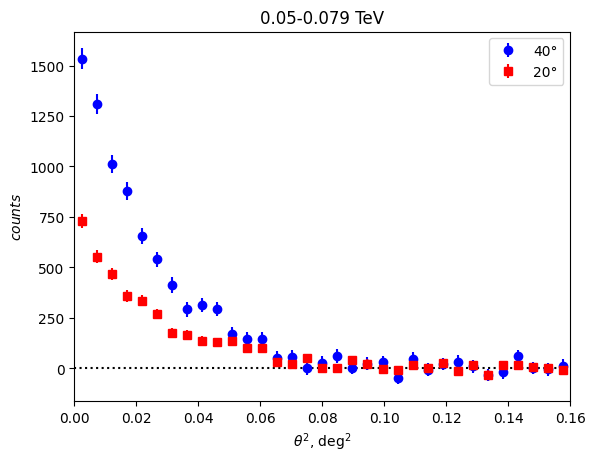

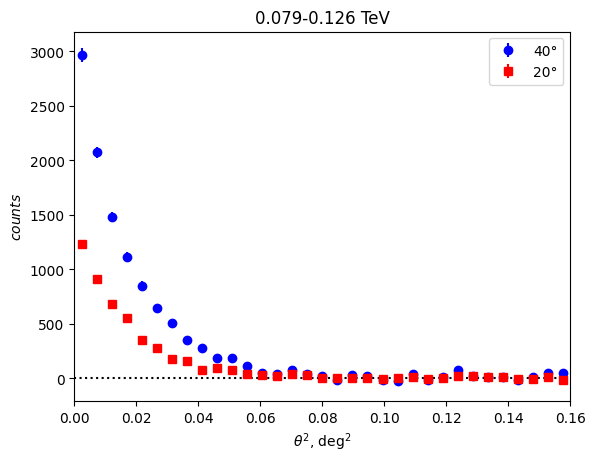

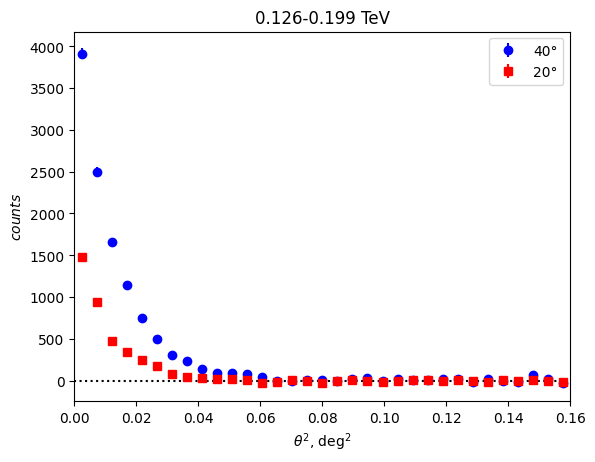

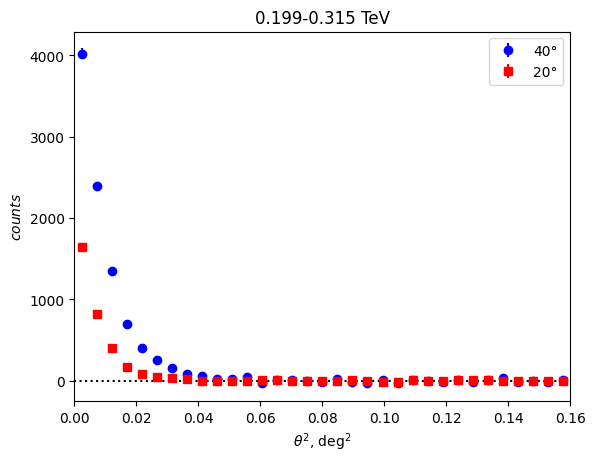

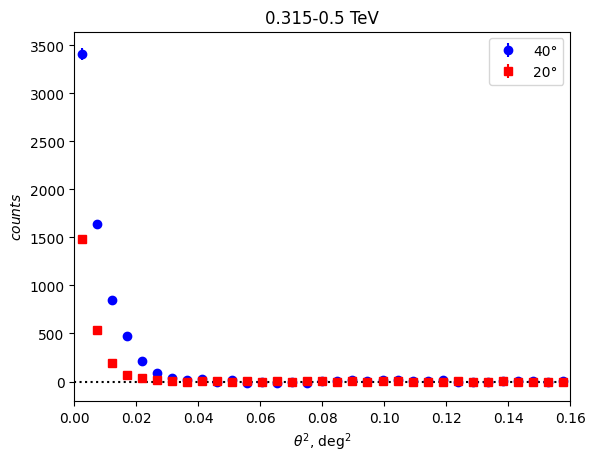

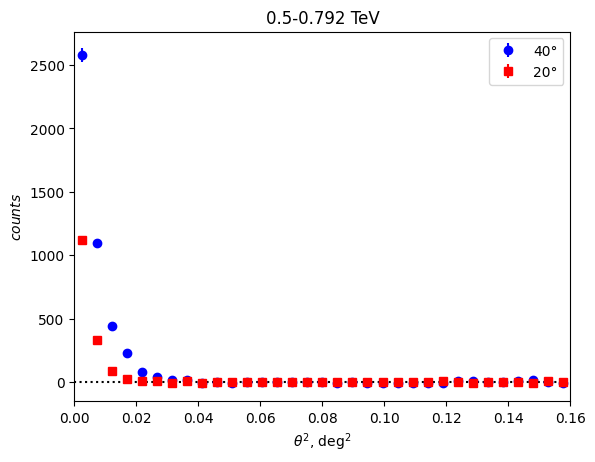

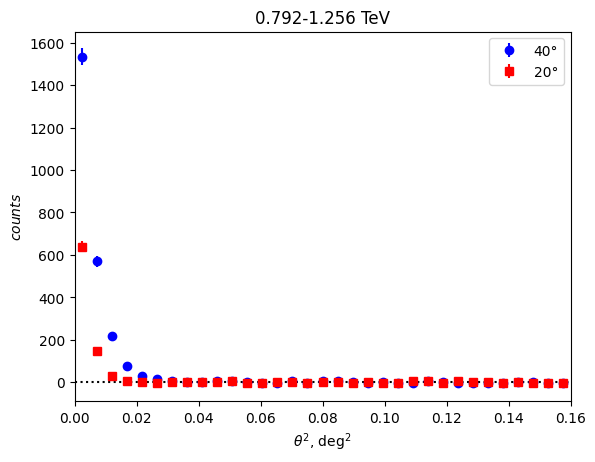

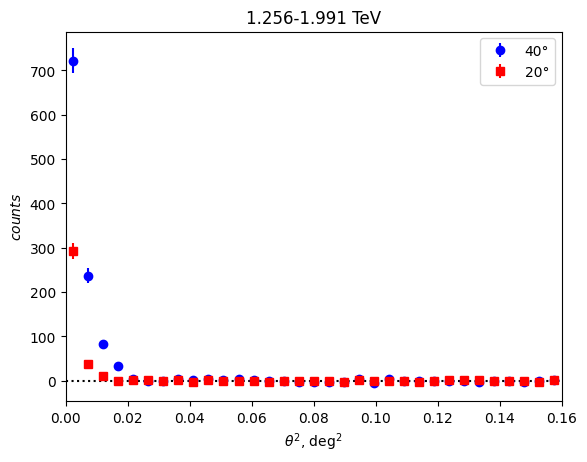

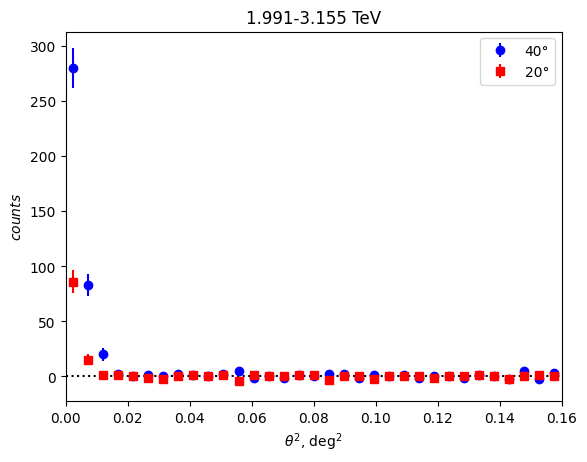

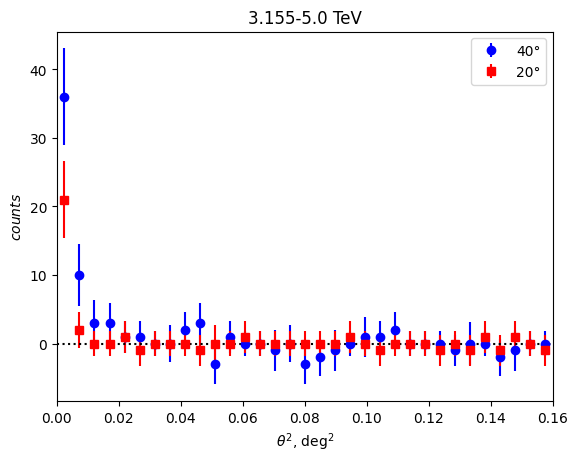

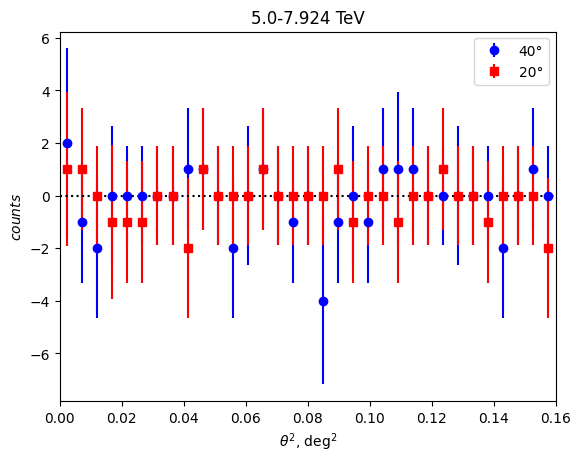

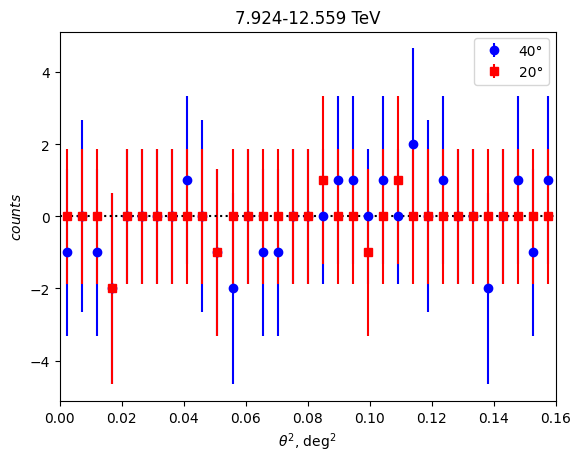

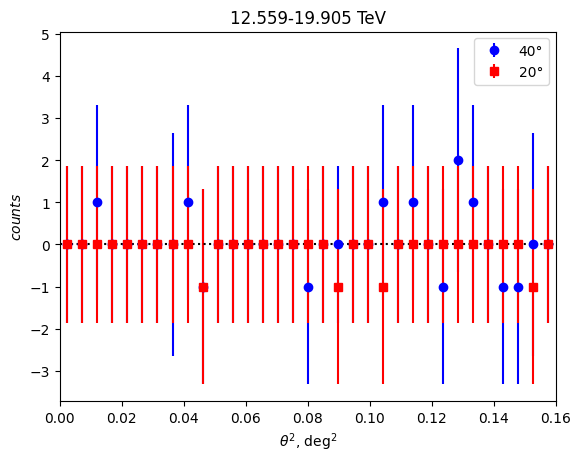

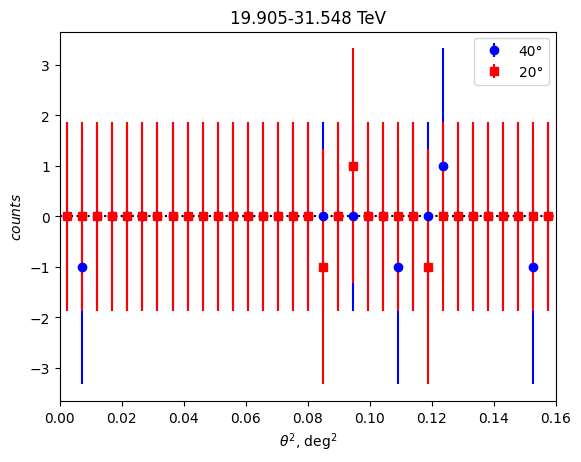

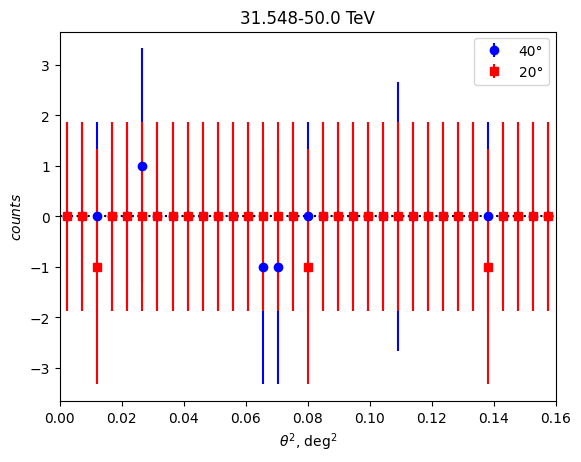

In [7]:
cts_40deg = cts_s_40deg - cts_b_40deg
cts_err_40deg = 1 + np.sqrt(cts_s_40deg + cts_b_40deg + 0.75)

cts_20deg = cts_s_20deg - cts_b_20deg
cts_err_20deg = 1 + np.sqrt(cts_s_20deg + cts_b_20deg + 0.75)

for i, ((cts_40, cts_err_40), (cts_20, cts_err_20)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
    plt.figure()
    plt.errorbar(th2, cts_40, cts_err_40, fmt='o', label='40°', color='blue')
    plt.errorbar(th2, cts_20, cts_err_20, fmt='s', label='20°', color='red')
    plt.axhline(0, color='black', linestyle='dotted')
    plt.xlim(0, 0.16)
    plt.title(str(round(e_mins[i],3)) + '-' + str(round(e_maxs[i],3)) + ' TeV')
    plt.xlabel(r'$\theta^2$, deg$^2$')
    plt.ylabel(r'$counts$')
    plt.legend()
    plt.show()

In [8]:
psf_hbu_40deg = irf_40deg["psf"]
psf_hbu_20deg = irf_20deg["psf"]

print(psf_hbu_40deg)
print(psf_hbu_40deg.info())
print(psf_hbu_40deg.data.shape)
# here i'm guessing the energy bins of the psf since idk how to see them.
psf_e_bins = np.logspace(np.log10(0.013), np.log10(199.526), 22)
psf_e_means = np.sqrt(psf_e_bins[1:]*psf_e_bins[:-1])
print(psf_e_bins)

EnergyDependentMultiGaussPSF
----------------------------

  axes      : ['energy_true', 'offset']
  shape     : (21, 6)
  ndim      : 2
  parameters: ['sigma_1', 'sigma_2', 'sigma_3', 'scale', 'ampl_2', 'ampl_3']


Summary PSF info
----------------
Theta          : size =     6, min =  0.500 deg, max =  5.500 deg
Energy hi      : size =    21, min =  0.020 TeV, max = 199.526 TeV
Energy lo      : size =    21, min =  0.013 TeV, max = 125.893 TeV
68.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.074 deg
95.00 containment radius at offset = 0.0 deg and energy_true =  1.0 TeV: 0.121 deg
68.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.062 deg
95.00 containment radius at offset = 0.0 deg and energy_true = 10.0 TeV: 0.100 deg

(21, 6)
[1.30000000e-02 2.05721347e-02 3.25548251e-02 5.15170959e-02
 8.15243565e-02 1.29010003e-01 2.04154705e-01 3.23069084e-01
 5.11247747e-01 8.09035193e-01 1.28027546e+00 2.02599994e+00
 3.20608797e+00 5.07354412

In [9]:
sigmas_ext = [0.1, 0.2, 0.3, 0.4]

In [10]:
def calculate_UL(cts, cts_err, psf_hbu):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    
    for i, (ct, ct_err) in enumerate(zip(cts, cts_err)):
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1, sigma_2, sigma_3, scale, ampl_2, ampl_3 = psf_hbu.data[psf_index][0]
    
        # Normalization of the PSF model to fit best the blazar
        def psf_model(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1**2))
            gauss2 = ampl_2*np.exp(-th2 / (2 * sigma_2**2))
            gauss3 = ampl_3*np.exp(-th2 / (2 * sigma_3**2))
            return (gauss1+gauss2+gauss3)

        # rescaling the psf component to match total counts of the data
        psf_component = psf_model(th2)
        psf_component = sum(ct)*psf_component/sum(psf_component)
        # The errors on the counts are independent, here I used this formula for error propagation:
        # z = \sum x_i, then z_err = sqrt(\sum x_i_err**2)
        # psf_component_err = np.sqrt(sum(ct_err**2))*psf_component/sum(psf_component) # THIS ERROR EXISTS IN THE FIRST PLACE???
        # Lets try without error
        psf_component_err = np.zeros_like(psf_component)
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
    
        # taken from andrii notebook, to fit with psf better:
        step=1.01
        chi2_noext_best=1e10
        adjust=1
        while(chi2_noext<chi2_noext_best):
            chi2_noext_best=chi2_noext
            
            chisq0=sum((ct-step*adjust*psf_component)**2/(ct_err**2+(step*adjust*psf_component_err)**2))
            chisq1=sum((ct-adjust*psf_component/step)**2/(ct_err**2+(adjust*psf_component_err/step)**2))
            chisq_vec=np.array([chisq0,chisq1])
            chi2_noext=min(chisq_vec)
            ind=np.argmin(chisq_vec)
            
            if(chi2_noext<chi2_noext_best):
                if(ind==0):
                    adjust*=step
                if(ind==1):
                    adjust/=step
                    
        psf_component *= adjust
        psf_component_err *= adjust
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
        
        fig, axs = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [2, 1]})
        fig.subplots_adjust(hspace=0)
        axs[0].errorbar(th2,ct,ct_err,linestyle='none',marker='o',label=name,color='black')
        axs[0].plot(th2,psf_component,color='black',linestyle='dashed',label='PSF')
        axs[0].fill_between(th2,(psf_component-psf_component_err),(psf_component+psf_component_err),color='black',alpha=0.1,linewidth=0)
        axs[0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1].errorbar(th2,ct - psf_component,np.sqrt(ct_err**2+psf_component_err**2),marker='o',linestyle='none',color='black')
        axs[1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            def ext_model(th2):
                sigma1_conv = np.sqrt(sigma_1**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3**2 + sigma_ext**2)
                c1 = sigma_1/(sigma_1**2 + sigma_ext**2)
                c2 = ampl_2*sigma_2/(sigma_2**2 + sigma_ext**2)
                c3 = ampl_3*sigma_3/(sigma_3**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return gauss1_conv + gauss2_conv + gauss3_conv
        
            ct_ext = ext_model(th2)
            ct_ext = sum(ct)*ct_ext/sum(ct_ext)
            ct_ext_plus_src = ct_ext+psf_component
            chi2_ext = np.sum(((ct - ct_ext_plus_src)**2 / (ct_err**2 + psf_component_err**2)))

            # Finding the best fit for psf*(extended + point)
            step=1.01
            chi2_ext_best = 1e10
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best):
                chi2_ext_best = chi2_ext
                #ct_ext_err*=adjust_ext for the moment without error
                
                chisq0=sum((ct-step*adjust_point*psf_component-adjust_ext*ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                chisq1=sum((ct-adjust_point*psf_component/step-adjust_ext*ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                chisq2=sum((ct-adjust_point*psf_component-step*adjust_ext*ct_ext)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq3=sum((ct-adjust_point*psf_component-adjust_ext*ct_ext/step)**2/(ct_err**2+adjust_point*psf_component_err**2))
                chisq_vec=np.array([chisq0,chisq1,chisq2,chisq3])
                chi2_ext=min(chisq_vec)
                ind=np.argmin(chisq_vec)
                
                if(chi2_ext<chi2_ext_best):
                    if(ind==0):
                        adjust_point*=step
                    if(ind==1):
                        adjust_point/=step
                    if(ind==2):
                        adjust_ext*=step
                    if(ind==3):
                        adjust_ext/=step

            ct_ext*=adjust_ext
            psf_component*=adjust_point
            psf_component_err*=adjust_point
            
            cts_tot_best = np.sum(ct_ext + psf_component)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            # Here chi2_ext is chi2_min, the best fit possible.
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")

            # Upper limits
            # We fix the extended normalization and keep the other parameters free. delta dof = 1.
            # We finish at chi2 - chi2_min \approx 2.71
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                # extended normalization fixed ...
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                # ... while we fit best with other parameters:
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext
                    
                    chisq0=sum((ct-step*adjust_point*psf_component-ct_ext)**2/(ct_err**2+(step*adjust_point*psf_component_err)**2))
                    chisq1=sum((ct-adjust_point*psf_component/step-ct_ext)**2/(ct_err**2+(adjust_point*psf_component_err/step)**2))
                    chisq_vec=np.array([chisq0,chisq1])
                    chi2_ext=min(chisq_vec)
                    ind=np.argmin(chisq_vec)
                    
                    if(chi2_ext<chi2_ext_best_fixed_ext):
                        if(ind==0):
                            adjust_point*=step
                        if(ind==1):
                            adjust_point/=step

            flux_ratios[k][i] = np.sum(ct_ext)/cts_tot_best
            axs[0].plot(th2,ct_ext,color='blue',alpha=0.5,linestyle='dashdot',label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0].set_ylabel('Counts')
        axs[0].legend()
        axs[0].set_yscale('log')
        plt.show()
    return flux_ratios

Best fit extended plus point gives chi2: 30.68960214744485
Best fit extended plus point gives chi2: 30.483197801104453
Best fit extended plus point gives chi2: 30.34629939511112
Best fit extended plus point gives chi2: 30.34785321474402


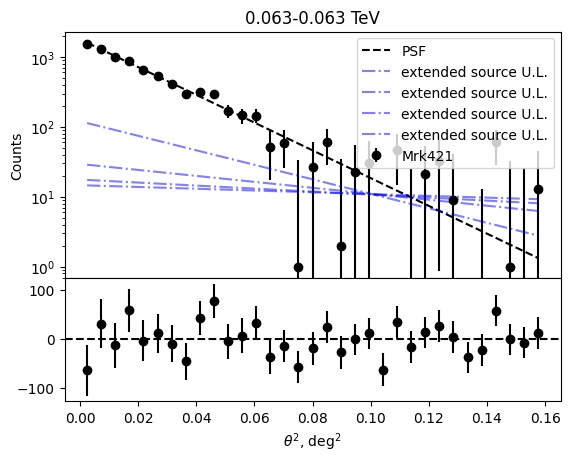

Best fit extended plus point gives chi2: 35.38582345100895
Best fit extended plus point gives chi2: 33.35217577687368
Best fit extended plus point gives chi2: 32.71664553992213
Best fit extended plus point gives chi2: 32.604353642091716


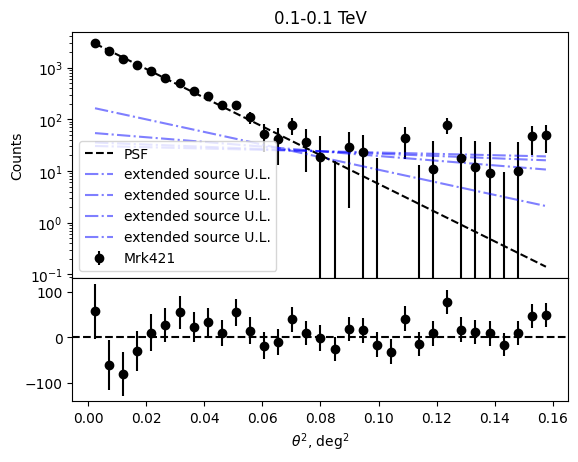

Best fit extended plus point gives chi2: 31.627500674656467
Best fit extended plus point gives chi2: 30.51256171940623
Best fit extended plus point gives chi2: 30.37764396412716
Best fit extended plus point gives chi2: 30.30294808718921


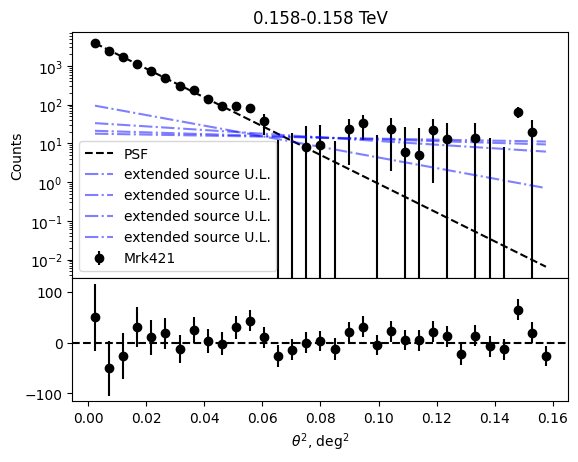

Best fit extended plus point gives chi2: 40.85841001093187
Best fit extended plus point gives chi2: 42.52504328233785
Best fit extended plus point gives chi2: 42.99088505727379
Best fit extended plus point gives chi2: 43.12598855830352


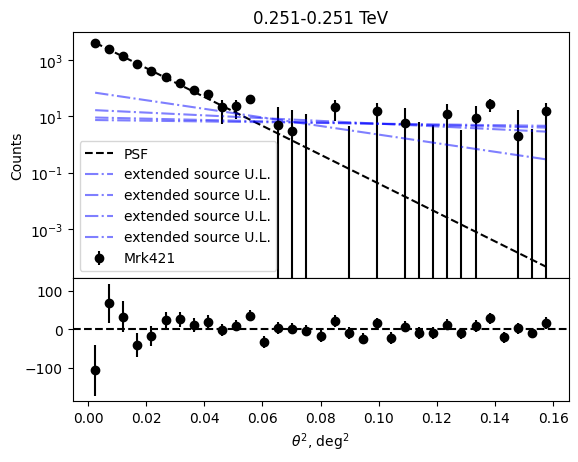

Best fit extended plus point gives chi2: 39.72999488977033
Best fit extended plus point gives chi2: 40.20196203710175
Best fit extended plus point gives chi2: 40.015290728719016
Best fit extended plus point gives chi2: 39.919199566519346


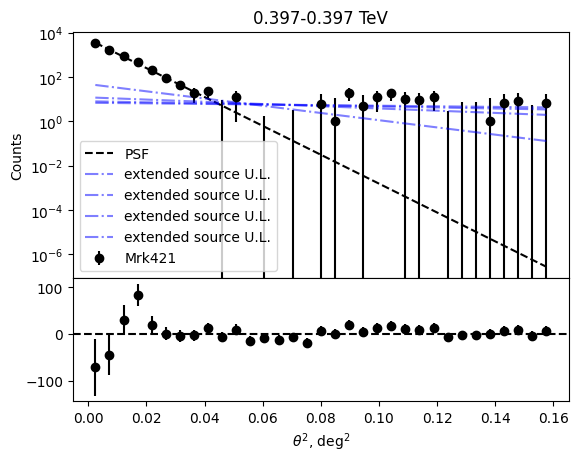

Best fit extended plus point gives chi2: 23.05678384548316
Best fit extended plus point gives chi2: 23.056783845483526
Best fit extended plus point gives chi2: 23.0567838454837
Best fit extended plus point gives chi2: 23.056783845483505


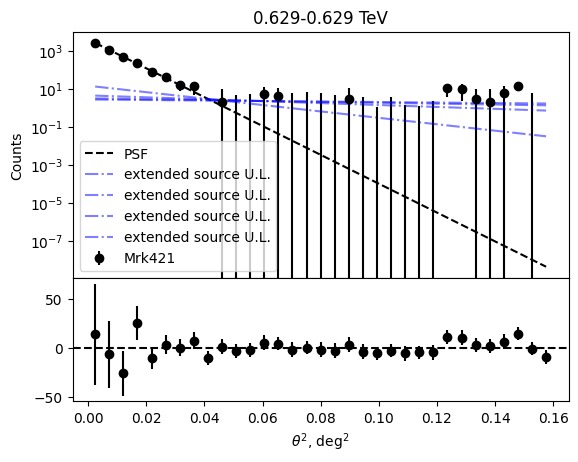

Best fit extended plus point gives chi2: 13.69357419459394
Best fit extended plus point gives chi2: 13.88009494519298
Best fit extended plus point gives chi2: 13.973738186904061
Best fit extended plus point gives chi2: 13.980729285294917


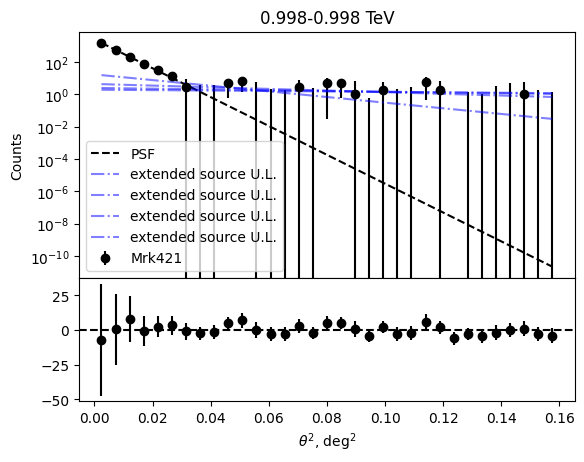

Best fit extended plus point gives chi2: 11.034213576976063
Best fit extended plus point gives chi2: 11.034213576976406
Best fit extended plus point gives chi2: 11.034213576976205
Best fit extended plus point gives chi2: 11.03421357697622


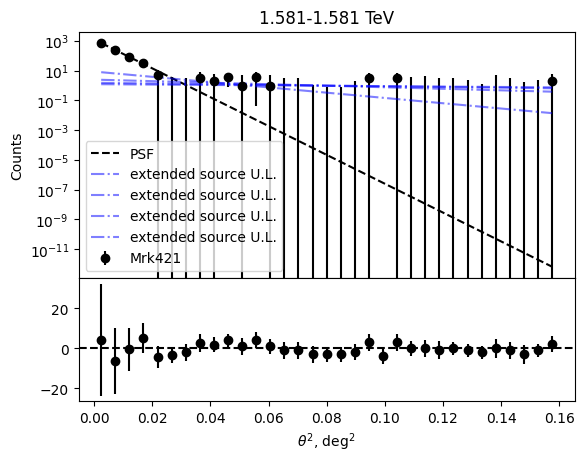

Best fit extended plus point gives chi2: 13.418339631251541
Best fit extended plus point gives chi2: 13.418339631251685
Best fit extended plus point gives chi2: 13.40637832976478
Best fit extended plus point gives chi2: 13.389619301235314


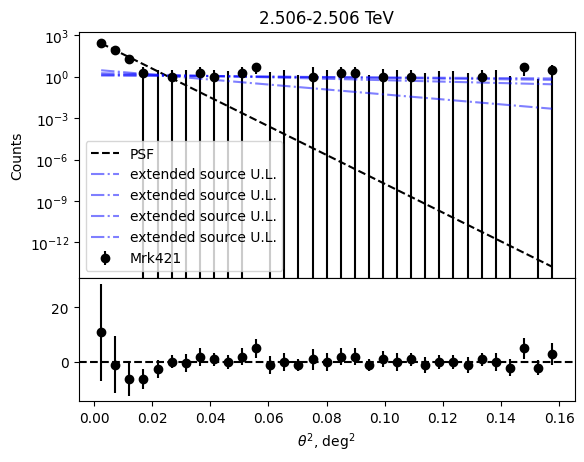

Best fit extended plus point gives chi2: 6.75610160897998
Best fit extended plus point gives chi2: 7.04523150304268
Best fit extended plus point gives chi2: 7.138794686396018
Best fit extended plus point gives chi2: 7.1596986790729815


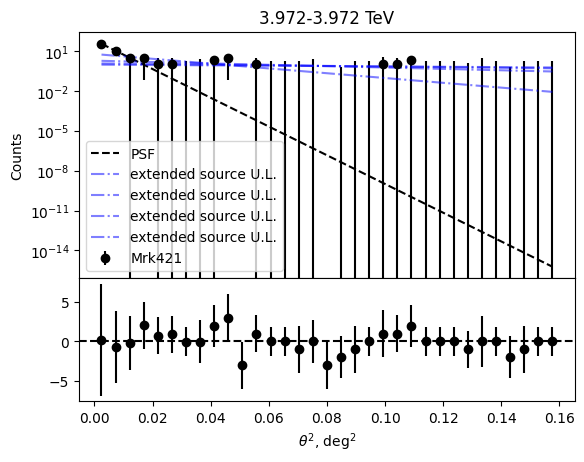

Best fit extended plus point gives chi2: 5.503922525824879
Best fit extended plus point gives chi2: 5.491730015575308
Best fit extended plus point gives chi2: 5.494570778392203
Best fit extended plus point gives chi2: 5.49845906522042


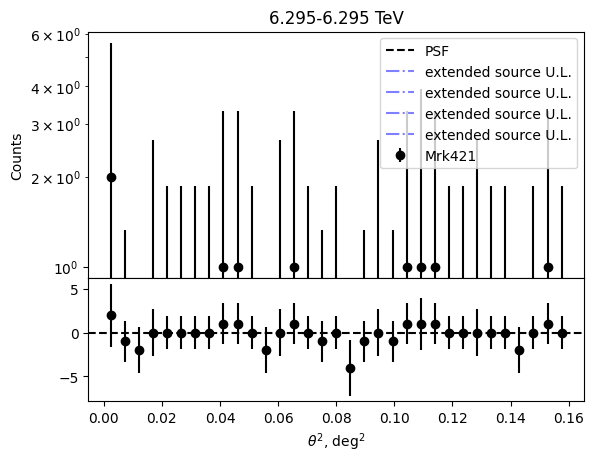

Best fit extended plus point gives chi2: 4.243799103421346
Best fit extended plus point gives chi2: 4.376777901039847
Best fit extended plus point gives chi2: 4.4390249428068564
Best fit extended plus point gives chi2: 4.4558540591494324


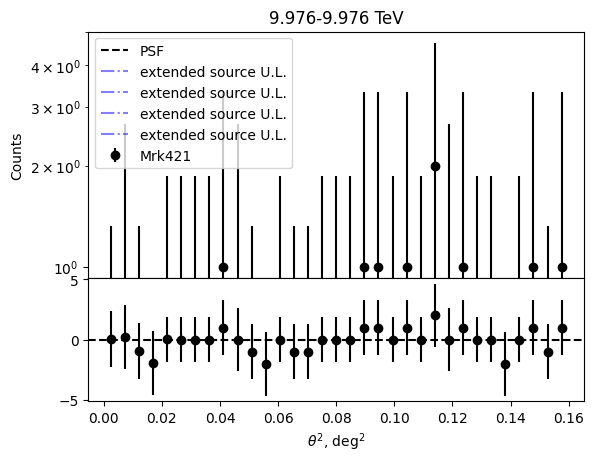

Best fit extended plus point gives chi2: 2.399122844301336
Best fit extended plus point gives chi2: 2.403013853020741
Best fit extended plus point gives chi2: 2.4058065768969823
Best fit extended plus point gives chi2: 2.407212562310317


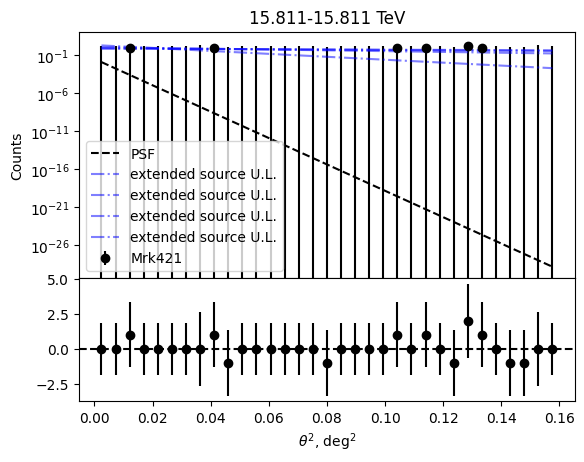

Best fit extended plus point gives chi2: 0.7111765835540856
Best fit extended plus point gives chi2: 0.7226448987309216
Best fit extended plus point gives chi2: 0.7248395065363566
Best fit extended plus point gives chi2: 0.7254812736457872


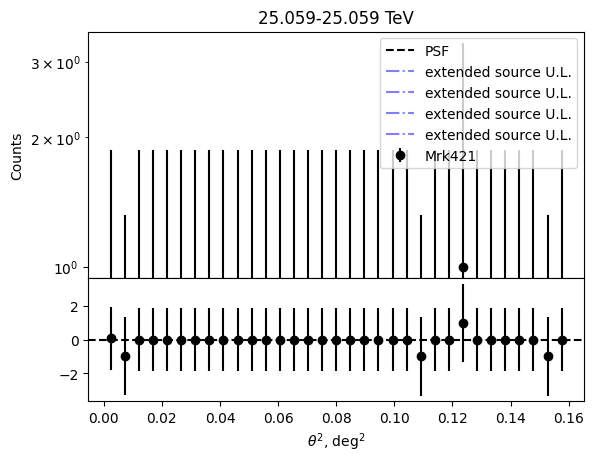

Best fit extended plus point gives chi2: 0.5559930076555467
Best fit extended plus point gives chi2: 0.5556520493426199
Best fit extended plus point gives chi2: 0.5538599935000955
Best fit extended plus point gives chi2: 0.5530527678650768


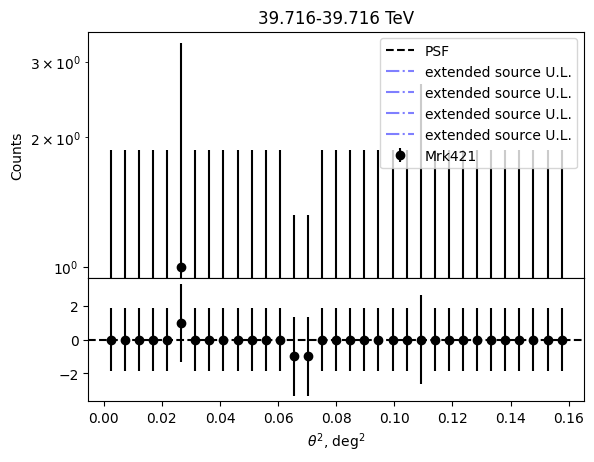

Best fit extended plus point gives chi2: 27.67159741676292
Best fit extended plus point gives chi2: 27.67159741676336
Best fit extended plus point gives chi2: 27.67159741676299
Best fit extended plus point gives chi2: 27.671597416763248


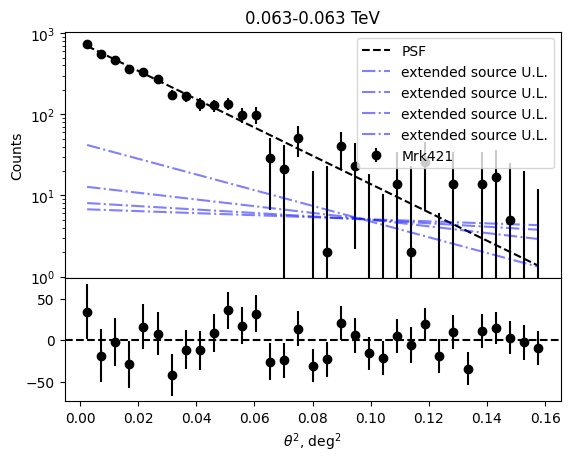

Best fit extended plus point gives chi2: 22.459307904560827
Best fit extended plus point gives chi2: 21.885315202322463
Best fit extended plus point gives chi2: 21.971807089021972
Best fit extended plus point gives chi2: 21.94149780541893


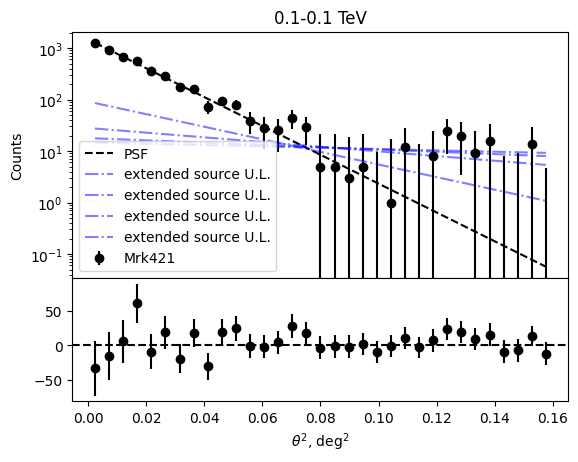

Best fit extended plus point gives chi2: 46.289284852963796
Best fit extended plus point gives chi2: 46.28928485296384
Best fit extended plus point gives chi2: 46.28928485296469
Best fit extended plus point gives chi2: 46.28928485296433


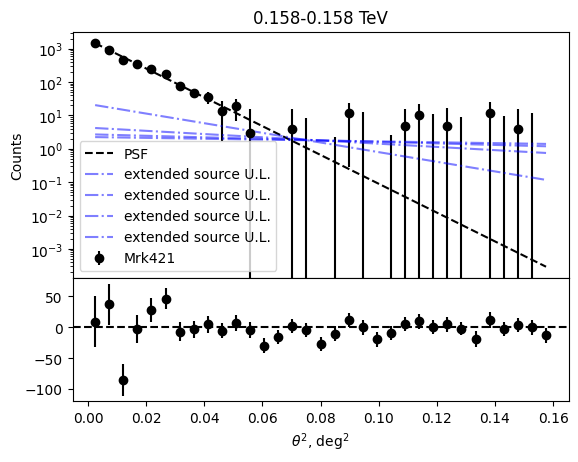

Best fit extended plus point gives chi2: 17.499880060069714
Best fit extended plus point gives chi2: 17.814005909627483
Best fit extended plus point gives chi2: 17.86780563688896
Best fit extended plus point gives chi2: 17.88153564107095


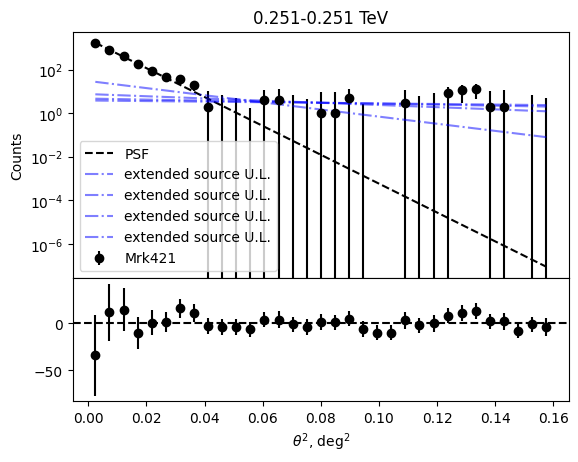

Best fit extended plus point gives chi2: 16.015910420696986
Best fit extended plus point gives chi2: 17.426187906313153
Best fit extended plus point gives chi2: 17.72618097596814
Best fit extended plus point gives chi2: 17.78764476347658


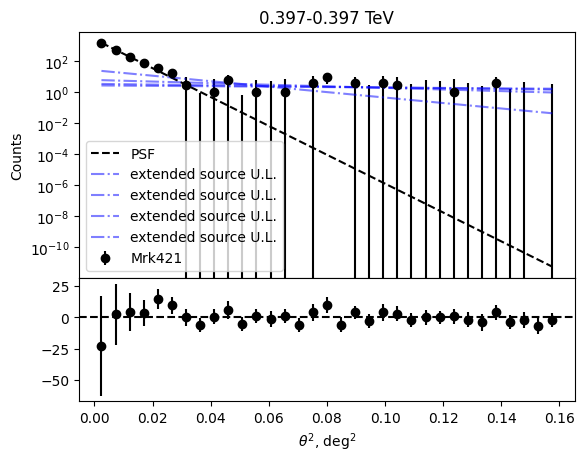

Best fit extended plus point gives chi2: 22.527744950008294
Best fit extended plus point gives chi2: 24.11481600387052
Best fit extended plus point gives chi2: 24.622022974537828
Best fit extended plus point gives chi2: 24.828048177097887


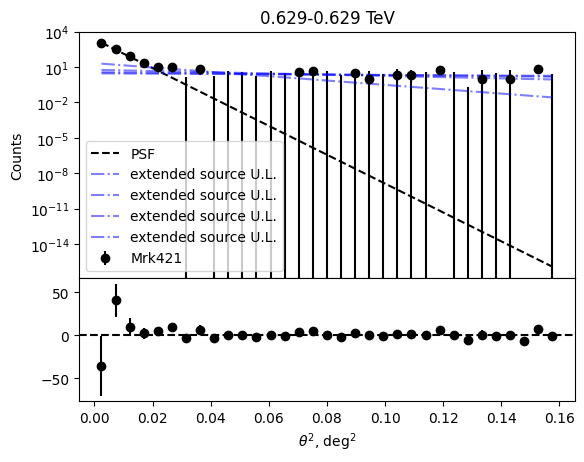

Best fit extended plus point gives chi2: 18.73978589116336
Best fit extended plus point gives chi2: 18.73978589116383
Best fit extended plus point gives chi2: 18.73978589116377
Best fit extended plus point gives chi2: 18.73978589116398


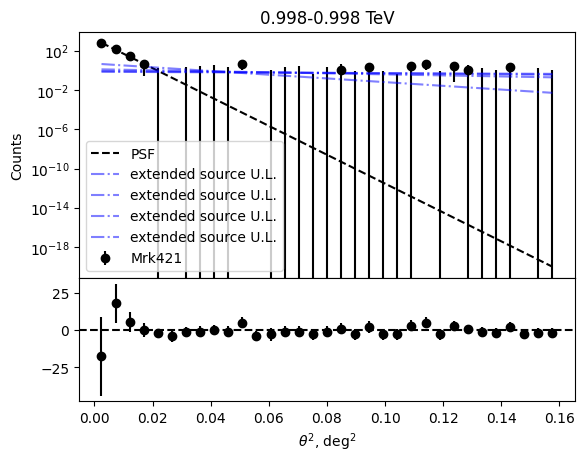

Best fit extended plus point gives chi2: 7.910934188779502
Best fit extended plus point gives chi2: 7.969457782375604
Best fit extended plus point gives chi2: 7.96945778237542
Best fit extended plus point gives chi2: 7.969457782375564


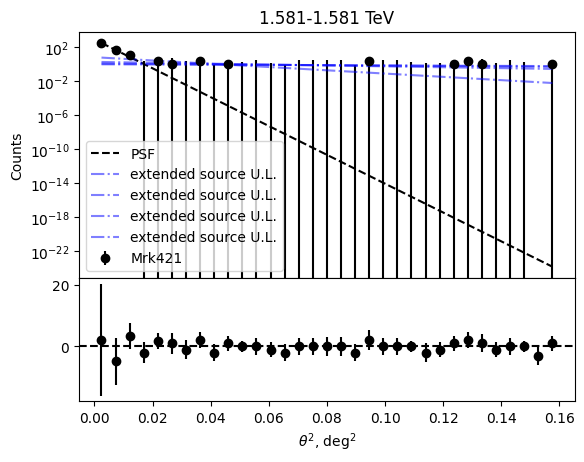

Best fit extended plus point gives chi2: 6.857906320184222
Best fit extended plus point gives chi2: 6.878740341683461
Best fit extended plus point gives chi2: 6.878740341683505
Best fit extended plus point gives chi2: 6.878740341683455


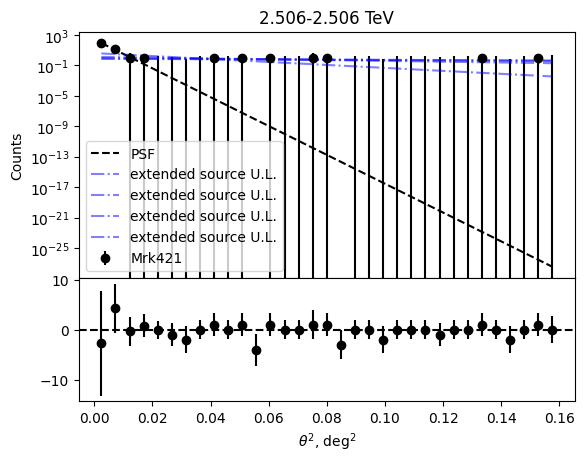

Best fit extended plus point gives chi2: 2.2464091121024126
Best fit extended plus point gives chi2: 2.2464091121023895
Best fit extended plus point gives chi2: 2.2464091121024325
Best fit extended plus point gives chi2: 2.24640911210242


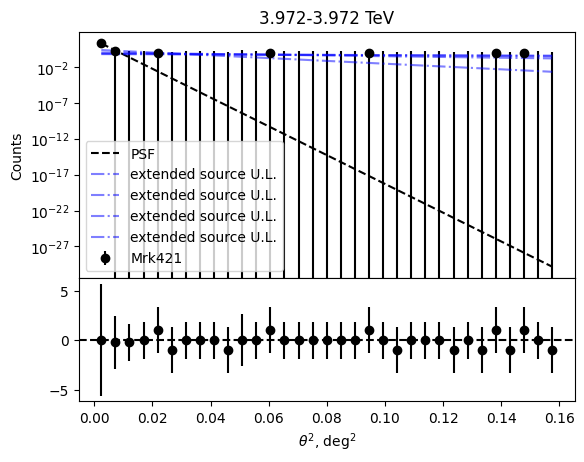

Best fit extended plus point gives chi2: 3.217330494420908
Best fit extended plus point gives chi2: 3.204507124186222
Best fit extended plus point gives chi2: 3.191647607511137
Best fit extended plus point gives chi2: 3.185505968028518


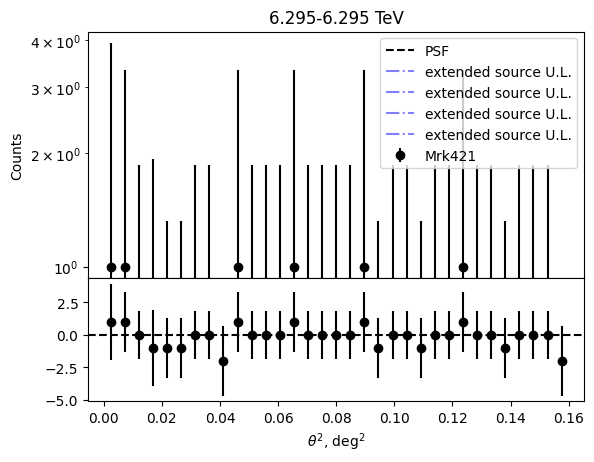

Best fit extended plus point gives chi2: 1.2733903896524816
Best fit extended plus point gives chi2: 1.274436854155907
Best fit extended plus point gives chi2: 1.2875759889653962
Best fit extended plus point gives chi2: 1.2925953859469832


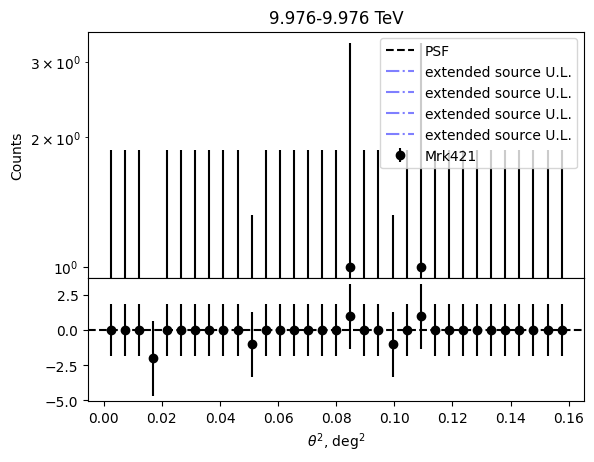

Best fit extended plus point gives chi2: 0.7403136181739282
Best fit extended plus point gives chi2: 0.7150573751945876
Best fit extended plus point gives chi2: 0.6961371345519853
Best fit extended plus point gives chi2: 0.6889404659972094


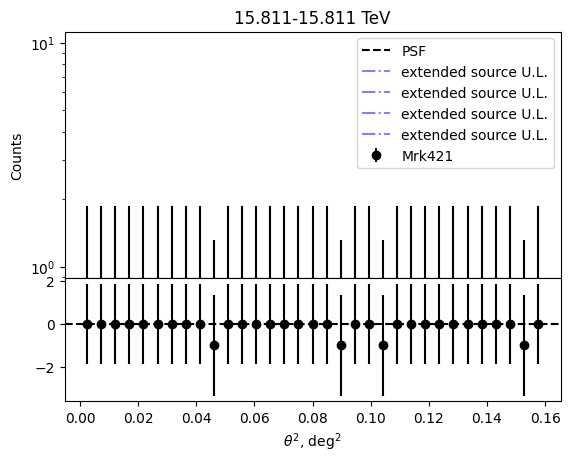

Best fit extended plus point gives chi2: 0.5559876357754769
Best fit extended plus point gives chi2: 0.5549152149140607
Best fit extended plus point gives chi2: 0.5535884972456209
Best fit extended plus point gives chi2: 0.5529952842336935


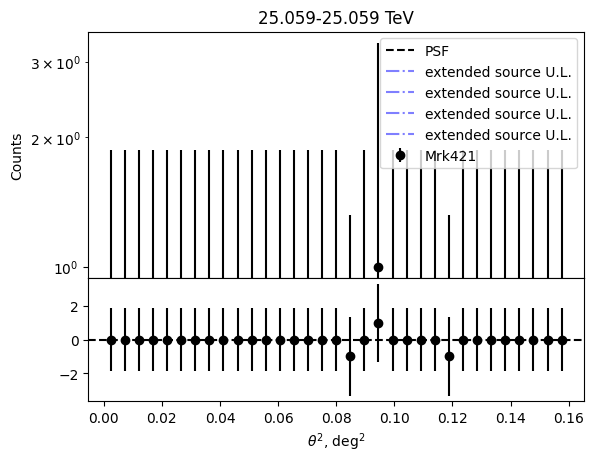

Best fit extended plus point gives chi2: 0.5359943218689355
Best fit extended plus point gives chi2: 0.5255609966965024
Best fit extended plus point gives chi2: 0.5225575929445103
Best fit extended plus point gives chi2: 0.5220881342026814


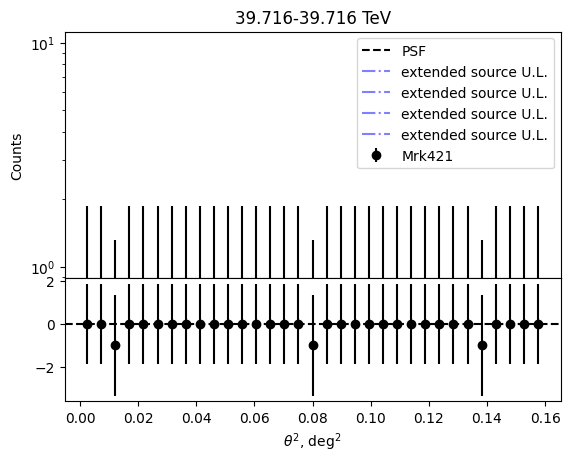

In [11]:
flux_ratios_40deg = calculate_UL(cts_40deg, cts_err_40deg, psf_hbu_40deg)
flux_ratios_20deg = calculate_UL(cts_20deg, cts_err_20deg, psf_hbu_20deg)

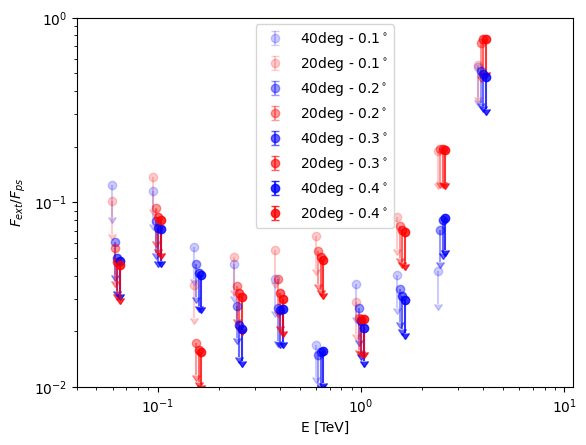

In [12]:
for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.01, 1)
plt.legend()

In [47]:
def calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg):
    flux_ratios = np.zeros((len(sigmas_ext), len(e)))
    th2_extended = np.concatenate([th2, th2])
    
    for i, ((ct_40deg, ct_err_40deg), (ct_20deg, ct_err_20deg)) in enumerate(zip(zip(cts_40deg, cts_err_40deg), zip(cts_20deg, cts_err_20deg))):
        ct = np.concatenate([ct_40deg, ct_20deg])
        ct_err = np.concatenate([ct_err_40deg, ct_err_20deg])
        # psf_index will store the best index for accessing the PSF values form the file.
        psf_index = np.argmin(np.abs(psf_e_means - e[i]))
        sigma_1_40deg, sigma_2_40deg, sigma_3_40deg, scale_40deg, ampl_2_40deg, ampl_3_40deg = psf_hbu_40deg.data[psf_index][0]
        sigma_1_20deg, sigma_2_20deg, sigma_3_20deg, scale_20deg, ampl_2_20deg, ampl_3_20deg = psf_hbu_20deg.data[psf_index][0]
        
        # Normalization of the PSF model to fit best the blazar
        def psf_model_40deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_40deg**2))
            gauss2 = ampl_2_40deg * np.exp(-th2 / (2 * sigma_2_40deg**2))
            gauss3 = ampl_3_40deg * np.exp(-th2 / (2 * sigma_3_40deg**2))
            return scale_40deg*(gauss1 + gauss2 + gauss3)
         
        def psf_model_20deg(th2):
            gauss1 = np.exp(-th2 / (2 * sigma_1_20deg**2))
            gauss2 = ampl_2_20deg * np.exp(-th2 / (2 * sigma_2_20deg**2))
            gauss3 = ampl_3_20deg * np.exp(-th2 / (2 * sigma_3_20deg**2))
            return scale_20deg*(gauss1 + gauss2 + gauss3)

        psf_component_40deg = psf_model_40deg(th2)
        psf_component_20deg = psf_model_20deg(th2)

        psf_component_40deg = sum(ct_40deg) * psf_component_40deg / sum(psf_component_40deg)
        psf_component_20deg = sum(ct_20deg) * psf_component_20deg / sum(psf_component_20deg)

        psf_component_err_40deg = np.zeros_like(psf_component_40deg)
        psf_component_err_20deg = np.zeros_like(psf_component_20deg)

        chi2_noext_40deg = np.sum(((ct_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))
        chi2_noext_20deg = np.sum(((ct_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))
    
        step = 1.01
        
        chi2_noext_best_40deg = 1e10
        adjust_40deg = 1
        while chi2_noext_40deg < chi2_noext_best_40deg:
            chi2_noext_best_40deg = chi2_noext_40deg
            
            chisq0 = sum((ct_40deg - step*adjust_40deg*psf_component_40deg)**2 / 
                         (ct_err_40deg**2 + (step*adjust_40deg*psf_component_err_40deg)**2))
            chisq1 = sum((ct_40deg - adjust_40deg*psf_component_40deg/step)**2 / 
                         (ct_err_40deg**2 + (adjust_40deg*psf_component_err_40deg/step)**2))
            chisq_vec = np.array([chisq0, chisq1])
            chi2_noext_40deg = min(chisq_vec)
            ind = np.argmin(chisq_vec)
            
            if chi2_noext_40deg < chi2_noext_best_40deg:
                if ind == 0:
                    adjust_40deg *= step
                elif ind == 1:
                    adjust_40deg /= step

        chi2_noext_best_20deg = 1e10
        adjust_20deg = 1
        while chi2_noext_20deg < chi2_noext_best_20deg:
            chi2_noext_best_20deg = chi2_noext_20deg
            
            chisq0 = sum((ct_20deg - step*adjust_20deg*psf_component_20deg)**2 / 
                         (ct_err_20deg**2 + (step*adjust_20deg*psf_component_err_20deg)**2))
            chisq1 = sum((ct_20deg - adjust_20deg*psf_component_20deg/step)**2 / 
                         (ct_err_20deg**2 + (adjust_20deg*psf_component_err_20deg/step)**2))
            chisq_vec = np.array([chisq0, chisq1])
            chi2_noext_20deg = min(chisq_vec)
            ind = np.argmin(chisq_vec)
            
            if chi2_noext_20deg < chi2_noext_best_20deg:
                if ind == 0:
                    adjust_20deg *= step
                elif ind == 1:
                    adjust_20deg /= step

        psf_component_40deg *= adjust_40deg
        psf_component_err_40deg *= adjust_40deg
        psf_component_20deg *= adjust_20deg
        psf_component_err_20deg *= adjust_20deg

        psf_component = np.concatenate([psf_component_40deg, psf_component_20deg])
        psf_component_err = np.concatenate([psf_component_err_40deg, psf_component_err_20deg])
        chi2_noext = np.sum(((ct - psf_component)**2 / (ct_err**2 + psf_component_err**2)))

        fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='row', gridspec_kw={'height_ratios': [2, 1], 'width_ratios': [1, 1]})
        fig.subplots_adjust(hspace=0, wspace=0.3)
        
        axs[0,0].errorbar(th2,ct_40deg,ct_err_40deg,linestyle='none',marker='o',label=name,color='black')
        axs[0,0].plot(th2,psf_component_40deg,color='black',linestyle='dashed',label='PSF')
        axs[0,0].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1,0].errorbar(th2,ct_40deg - psf_component_40deg,np.sqrt(ct_err_40deg**2+psf_component_err_40deg**2),marker='o',linestyle='none',color='black')
        axs[1,0].axhline(0,color='black',linestyle='dashed')
        axs[0,1].errorbar(th2,ct_20deg,ct_err_20deg,linestyle='none',marker='o',label=name,color='black')
        axs[0,1].plot(th2,psf_component_20deg,color='black',linestyle='dashed',label='PSF')
        axs[0,1].set_title(str(round(e[i],3))+'-'+str(round(e[i],3))+r' TeV')
        axs[1,1].errorbar(th2,ct_20deg - psf_component_20deg,np.sqrt(ct_err_20deg**2+psf_component_err_20deg**2),marker='o',linestyle='none',color='black')
        axs[1,1].axhline(0,color='black',linestyle='dashed')
    
        # For each sigma_ext: add a gaussian term norm_ext*gauss(sigma_ext) convolved with the psf, to the point source model (psf only), until delta_chi2 is > 2.71.
        # With this you found norm_ext such that the fit breaks. Lets call this norm_ext_br
        # Then the upper limit to the detectable ext. emission should be given by an extended emission of the form of: norm_ext_br*gauss(sigma_ext).
        for k, sigma_ext in enumerate(sigmas_ext):
            
            # CHANGES CONTINUE
            
            def ext_model_40deg(th2):
                sigma1_conv = np.sqrt(sigma_1_40deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_40deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_40deg**2 + sigma_ext**2)
                c1 = sigma_1_40deg/(sigma_1_40deg**2 + sigma_ext**2)
                c2 = ampl_2_40deg*sigma_2_40deg/(sigma_2_40deg**2 + sigma_ext**2)
                c3 = ampl_3_40deg*sigma_3_40deg/(sigma_3_40deg**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return scale_40deg*(gauss1_conv + gauss2_conv + gauss3_conv)

            def ext_model_20deg(th2):
                sigma1_conv = np.sqrt(sigma_1_20deg**2 + sigma_ext**2)
                sigma2_conv = np.sqrt(sigma_2_20deg**2 + sigma_ext**2)
                sigma3_conv = np.sqrt(sigma_3_20deg**2 + sigma_ext**2)
                c1 = sigma_1_20deg/(sigma_1_20deg**2 + sigma_ext**2)
                c2 = ampl_2_20deg*sigma_2_20deg/(sigma_2_20deg**2 + sigma_ext**2)
                c3 = ampl_3_20deg*sigma_3_20deg/(sigma_3_20deg**2 + sigma_ext**2)
                gauss1_conv = c1 * np.exp(-th2 / (2 * sigma1_conv**2))
                gauss2_conv = c2 * np.exp(-th2 / (2 * sigma2_conv**2))
                gauss3_conv = c3 * np.exp(-th2 / (2 * sigma3_conv**2))
                return scale_20deg*(gauss1_conv + gauss2_conv + gauss3_conv)

            ct_ext_40deg = ext_model_40deg(th2)
            ct_ext_20deg = ext_model_20deg(th2)

            ct_ext_40deg = sum(ct_40deg) * ct_ext_40deg / sum(ct_ext_40deg)
            ct_ext_20deg = sum(ct_20deg) * ct_ext_20deg / sum(ct_ext_20deg)

            chi2_ext_40deg = np.sum(((ct_40deg - ct_ext_40deg - psf_component_40deg)**2 / (ct_err_40deg**2 + psf_component_err_40deg**2)))
            chi2_ext_20deg = np.sum(((ct_20deg - ct_ext_20deg - psf_component_20deg)**2 / (ct_err_20deg**2 + psf_component_err_20deg**2)))

            step = 1.01
            
            chi2_ext_best_40deg = 1e10
            adjust_ext_40deg = 1
            adjust_point_40deg = 1
            
            while chi2_ext_40deg < chi2_ext_best_40deg:
                chi2_ext_best_40deg = chi2_ext_40deg
                
                chisq0 = sum((ct_40deg - step*adjust_point_40deg*psf_component_40deg - adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + (step*adjust_point_40deg*psf_component_err_40deg)**2))
                chisq1 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg/step - adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + (adjust_point_40deg*psf_component_err_40deg/step)**2))
                chisq2 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg - step*adjust_ext_40deg*ct_ext_40deg)**2 / 
                             (ct_err_40deg**2 + adjust_point_40deg*psf_component_err_40deg**2))
                chisq3 = sum((ct_40deg - adjust_point_40deg*psf_component_40deg - adjust_ext_40deg*ct_ext_40deg/step)**2 / 
                             (ct_err_40deg**2 + adjust_point_40deg*psf_component_err_40deg**2))
                
                chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                chi2_ext_40deg = min(chisq_vec)
                ind = np.argmin(chisq_vec)
                
                if chi2_ext_40deg < chi2_ext_best_40deg:
                    if ind == 0:
                        adjust_point_40deg *= step
                    if ind == 1:
                        adjust_point_40deg /= step
                    if ind == 2:
                        adjust_ext_40deg *= step
                    if ind == 3:
                        adjust_ext_40deg /= step

            chi2_ext_best_20deg = 1e10
            adjust_ext_20deg = 1
            adjust_point_20deg = 1
            
            while chi2_ext_20deg < chi2_ext_best_20deg:
                chi2_ext_best_20deg = chi2_ext_20deg
                
                chisq0 = sum((ct_20deg - step*adjust_point_20deg*psf_component_20deg - adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + (step*adjust_point_20deg*psf_component_err_20deg)**2))
                chisq1 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg/step - adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + (adjust_point_20deg*psf_component_err_20deg/step)**2))
                chisq2 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg - step*adjust_ext_20deg*ct_ext_20deg)**2 / 
                             (ct_err_20deg**2 + adjust_point_20deg*psf_component_err_20deg**2))
                chisq3 = sum((ct_20deg - adjust_point_20deg*psf_component_20deg - adjust_ext_20deg*ct_ext_20deg/step)**2 / 
                             (ct_err_20deg**2 + adjust_point_20deg*psf_component_err_20deg**2))
                
                chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                chi2_ext_20deg = min(chisq_vec)
                ind = np.argmin(chisq_vec)
                
                if chi2_ext_20deg < chi2_ext_best_20deg:
                    if ind == 0:
                        adjust_point_20deg *= step
                    if ind == 1:
                        adjust_point_20deg /= step
                    if ind == 2:
                        adjust_ext_20deg *= step
                    if ind == 3:
                        adjust_ext_20deg /= step
            
            ct_ext_40deg *= adjust_ext_40deg
            psf_component_40deg *= adjust_point_40deg
            psf_component_err_40deg *= adjust_point_40deg

            ct_ext_20deg *= adjust_ext_20deg
            psf_component_20deg *= adjust_point_20deg
            psf_component_err_20deg *= adjust_point_20deg

            # From now on i keep the calues concatenated. I'm renomalizing the extended component equally for the two zenith angles.
            # This might be wrong, I still have to think about it.
            ct_ext = np.concatenate([ct_ext_40deg, ct_ext_20deg])
            psf_component = np.concatenate([psf_component_40deg, psf_component_20deg])
            psf_component_err = np.concatenate([psf_component_err_40deg, psf_component_err_20deg])
            cts_tot_best = np.sum(ct_ext + psf_component)
            chi2_ext = np.sum(((ct - ct_ext - psf_component)**2 / (ct_err**2 + psf_component_err**2)))
            
            chi2_ext_best = chi2_ext
            ct_ext_best = ct_ext
            print(f"Best fit extended plus point gives chi2: {chi2_ext}")
            axs[0,0].plot(th2,ct_ext[:len(th2)],color='red',alpha=0.5,marker='+', linestyle="none",label='extended source best fit')
            axs[0,1].plot(th2,ct_ext[len(th2):],color='red',alpha=0.5,marker='+', linestyle="none",label='extended source best fit')

            # Upper limits
            step=1.01
            chi2_ext_best = chi2_ext
            adjust_ext = 1
            adjust_point_20deg_ul = 1
            adjust_point_40deg_ul = 1
            while(chi2_ext < chi2_ext_best + 2.71):
                adjust_ext *= step
                ct_ext = ct_ext_best*adjust_ext
                chi2_ext = np.sum(((ct - psf_component - ct_ext)**2 / (ct_err**2 + psf_component_err**2)))

                chi2_ext_best_fixed_ext = 1e10
                while(chi2_ext < chi2_ext_best_fixed_ext):
                    chi2_ext_best_fixed_ext = chi2_ext

                    chisq0 = sum((ct - ct_ext - np.concatenate([step*adjust_point_40deg_ul*psf_component_40deg, 
                                                                 adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)

                    chisq1 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg/step, 
                                                                 adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq2 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg, 
                                                                 step*adjust_point_20deg_ul*psf_component_20deg]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq3 = sum((ct - ct_ext - np.concatenate([adjust_point_40deg_ul*psf_component_40deg, 
                                                                 adjust_point_20deg_ul*psf_component_20deg/step]))**2 / np.concatenate([ct_err_40deg, ct_err_20deg])**2)
                    
                    chisq_vec = np.array([chisq0, chisq1, chisq2, chisq3])
                    chi2_ext = min(chisq_vec)
                    ind = np.argmin(chisq_vec)
                    
                    if chi2_ext < chi2_ext_best_fixed_ext:
                        if ind == 0:
                            adjust_point_40deg_ul *= step
                        elif ind == 1:
                            adjust_point_40deg_ul /= step
                        elif ind == 2:
                            adjust_point_20deg_ul *= step
                        elif ind == 3:
                            adjust_point_20deg_ul /= step

            flux_ratio = np.sum(ct_ext)/cts_tot_best
            flux_ratios[k][i] = flux_ratio
            axs[0,0].plot(th2,ct_ext[:len(th2)],color='blue',alpha=0.5,marker='+', linestyle="none",label='extended source U.L.')
            axs[0,1].plot(th2,ct_ext[len(th2):],color='blue',alpha=0.5,marker='+', linestyle="none",label='extended source U.L.')
            
        plt.xlabel(r'$\theta^2$, deg$^2$')
        axs[0,0].set_ylabel('Counts')
        axs[0,0].legend()
        axs[0,0].set_yscale('log')
        axs[0,1].set_ylabel('Counts')
        axs[0,1].legend()
        axs[0,1].set_yscale('log')
        plt.show()
    return flux_ratios

Best fit extended plus point gives chi2: 58.361199564208015
Best fit extended plus point gives chi2: 58.15479521786731
Best fit extended plus point gives chi2: 58.017896811874174
Best fit extended plus point gives chi2: 58.01945063150752


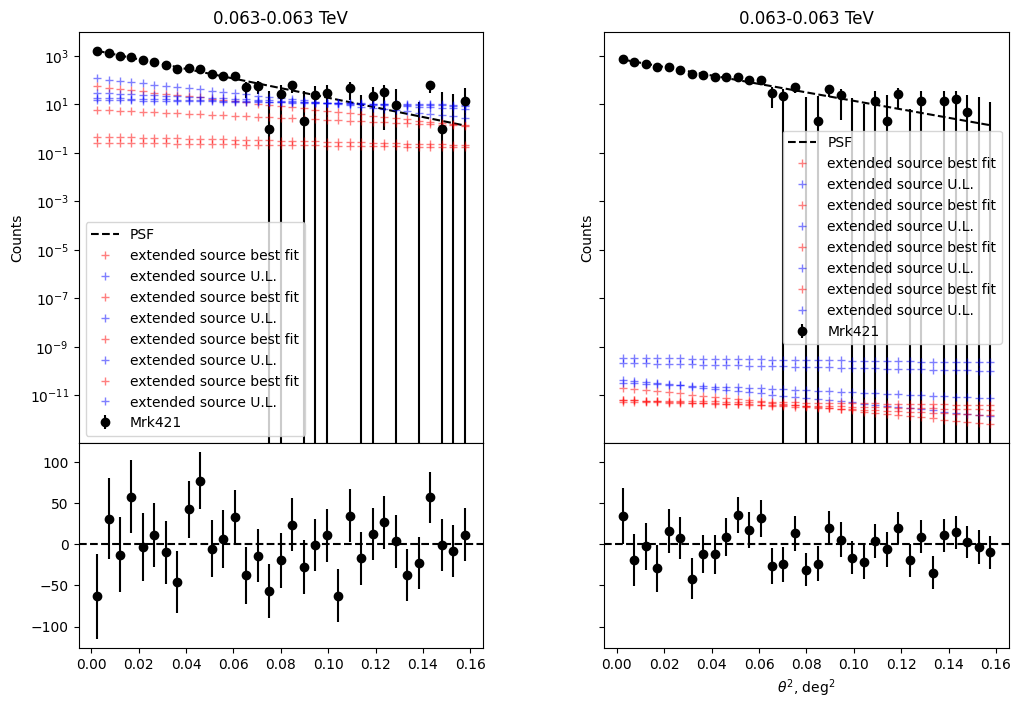

Best fit extended plus point gives chi2: 57.84513135556977
Best fit extended plus point gives chi2: 55.23749097919612
Best fit extended plus point gives chi2: 54.6884526289441
Best fit extended plus point gives chi2: 54.545851447510614


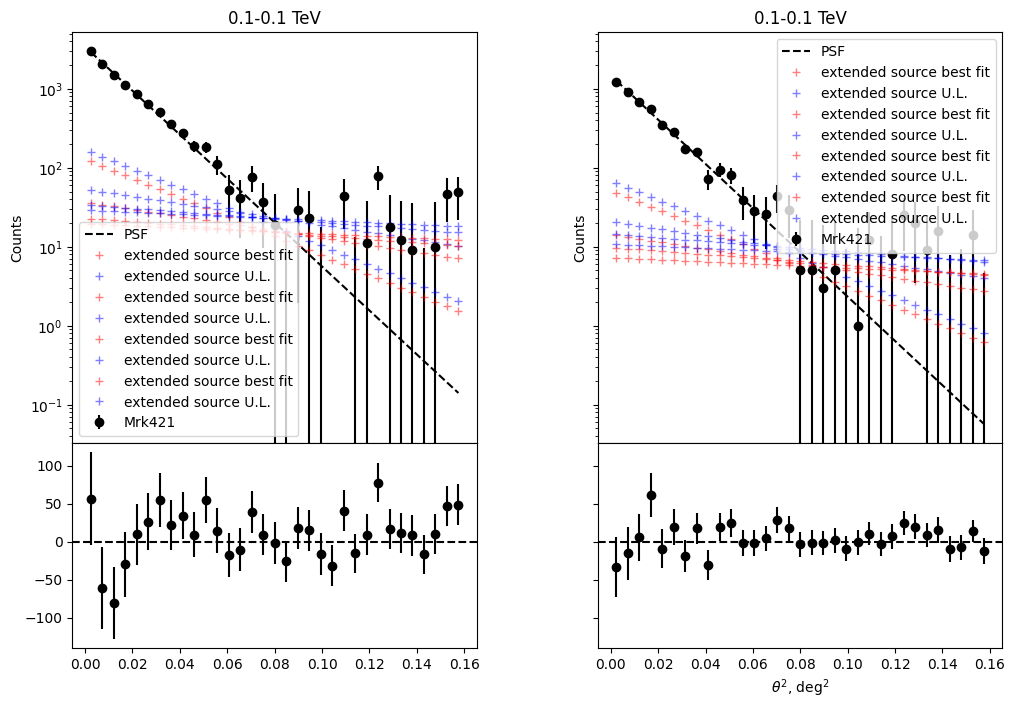

Best fit extended plus point gives chi2: 77.91678552762026
Best fit extended plus point gives chi2: 76.80184657237005
Best fit extended plus point gives chi2: 76.6669288170918
Best fit extended plus point gives chi2: 76.59223294015322


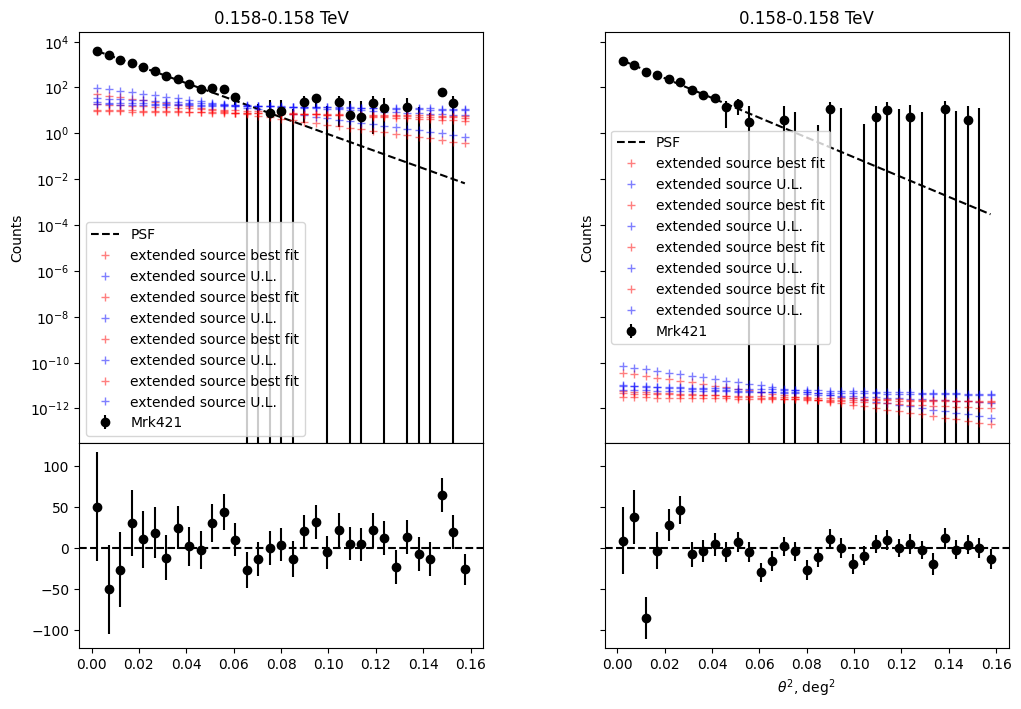

Best fit extended plus point gives chi2: 58.35829007100164
Best fit extended plus point gives chi2: 60.33904919196538
Best fit extended plus point gives chi2: 60.85869069416282
Best fit extended plus point gives chi2: 61.00752419937453


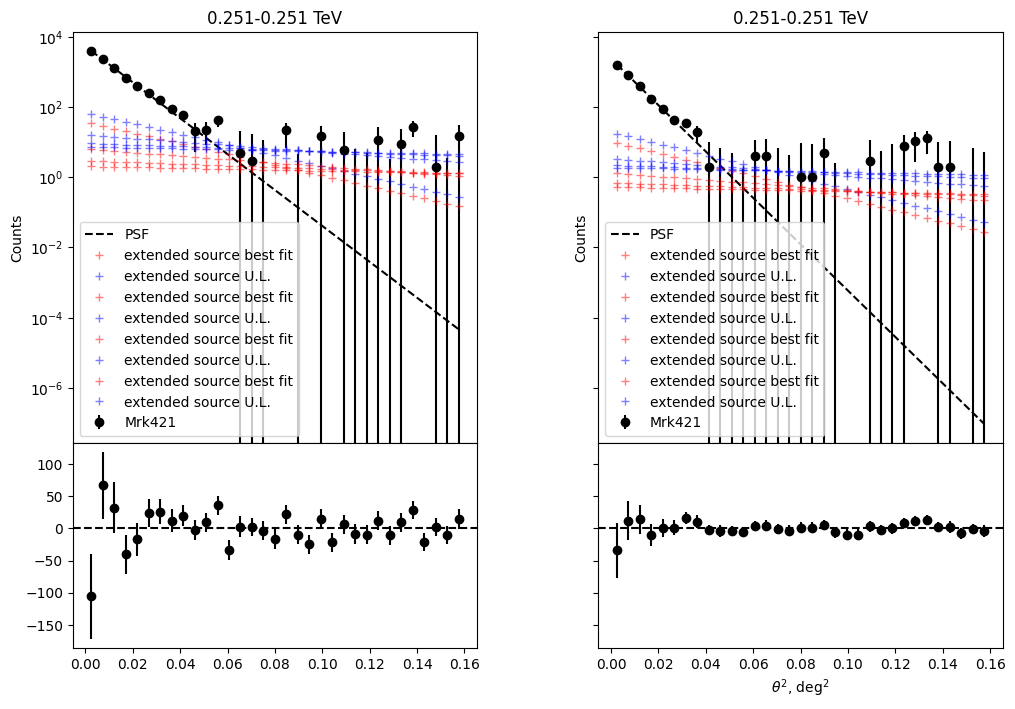

Best fit extended plus point gives chi2: 55.74590531046731
Best fit extended plus point gives chi2: 57.62814994341488
Best fit extended plus point gives chi2: 57.741471704687164
Best fit extended plus point gives chi2: 57.70684432999593


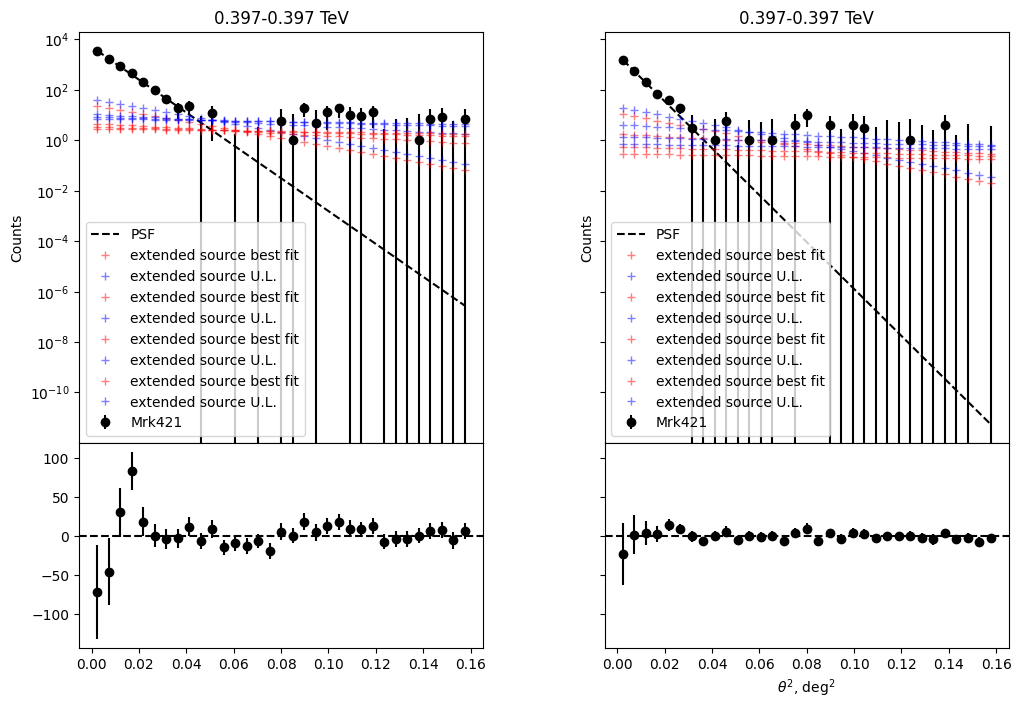

Best fit extended plus point gives chi2: 45.58452879549157
Best fit extended plus point gives chi2: 47.17159984935378
Best fit extended plus point gives chi2: 47.67880682002141
Best fit extended plus point gives chi2: 47.88483202258127


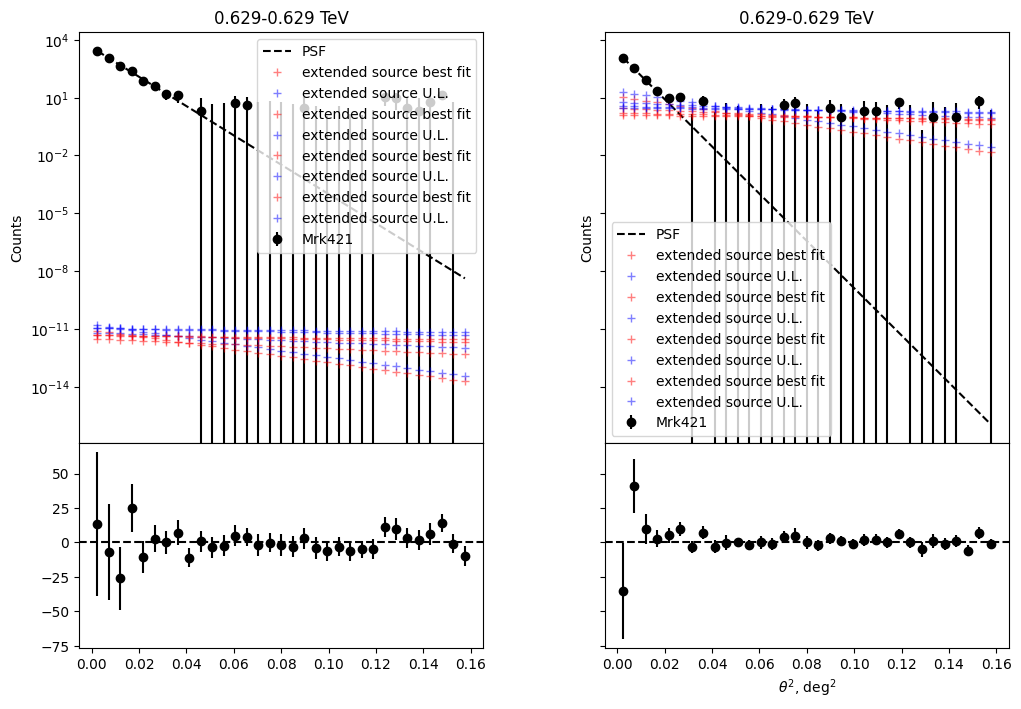

Best fit extended plus point gives chi2: 32.43336008575729
Best fit extended plus point gives chi2: 32.619880836356806
Best fit extended plus point gives chi2: 32.713524078068154
Best fit extended plus point gives chi2: 32.72051517645875


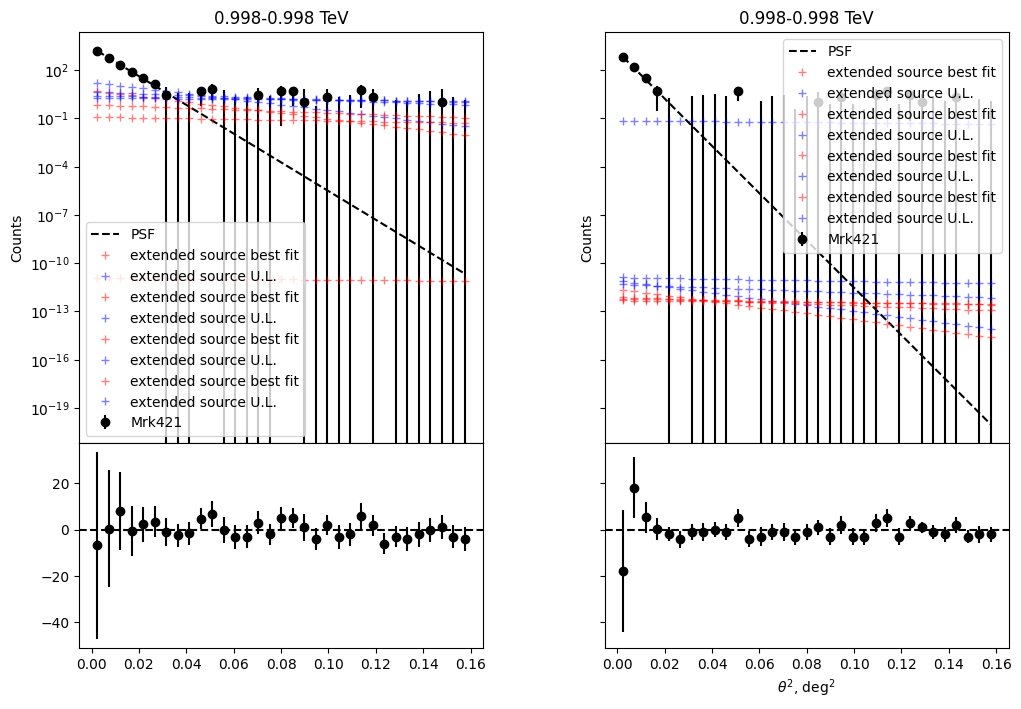

Best fit extended plus point gives chi2: 18.945147765755564
Best fit extended plus point gives chi2: 19.003671359351774
Best fit extended plus point gives chi2: 19.003671359351625
Best fit extended plus point gives chi2: 19.003671359351706


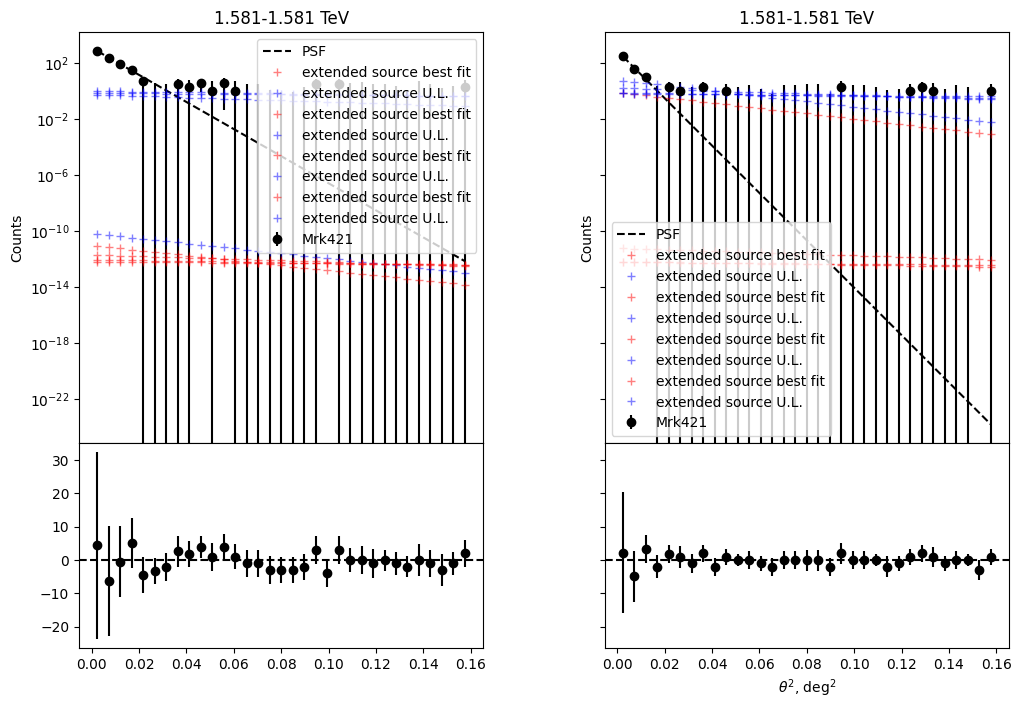

Best fit extended plus point gives chi2: 20.27624595143575
Best fit extended plus point gives chi2: 20.29707997293515
Best fit extended plus point gives chi2: 20.285118671448267
Best fit extended plus point gives chi2: 20.268359642918792


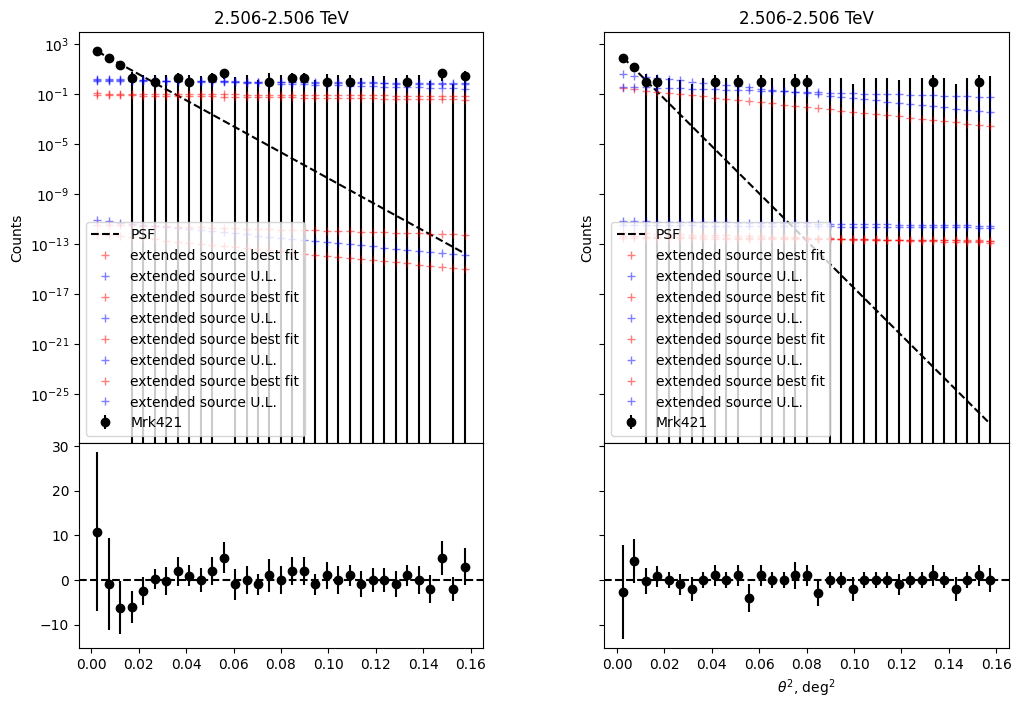

Best fit extended plus point gives chi2: 9.002510721082393
Best fit extended plus point gives chi2: 9.291640615145083
Best fit extended plus point gives chi2: 9.38520379849845
Best fit extended plus point gives chi2: 9.406107791175401


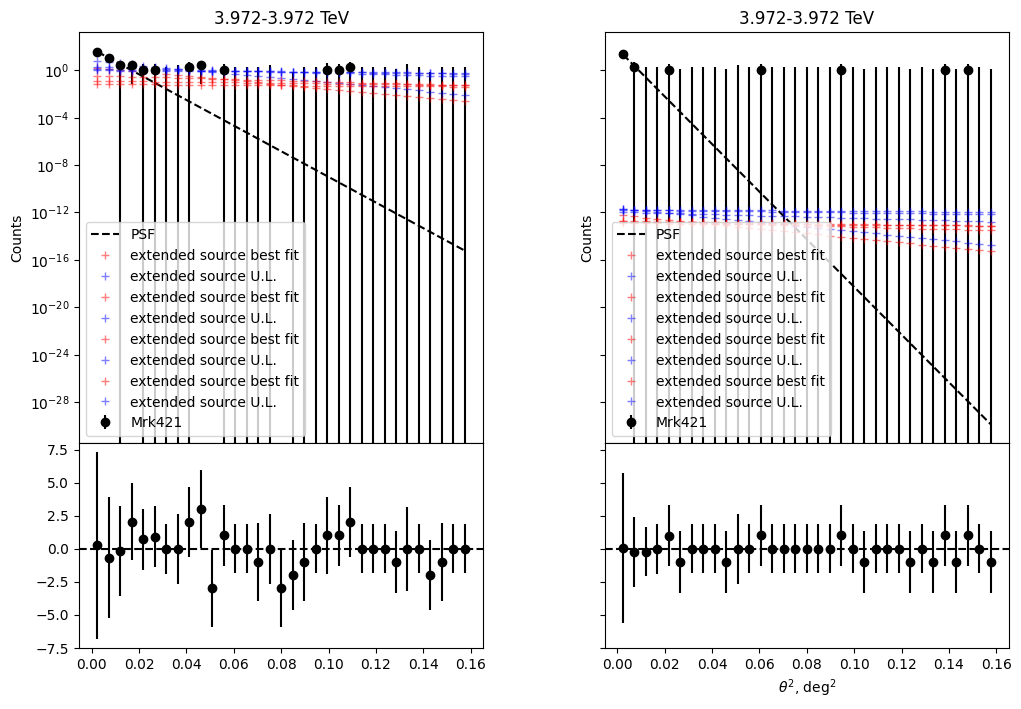

Best fit extended plus point gives chi2: 8.721253020245792
Best fit extended plus point gives chi2: 8.69623713976153
Best fit extended plus point gives chi2: 8.686218385903341
Best fit extended plus point gives chi2: 8.683965033248935


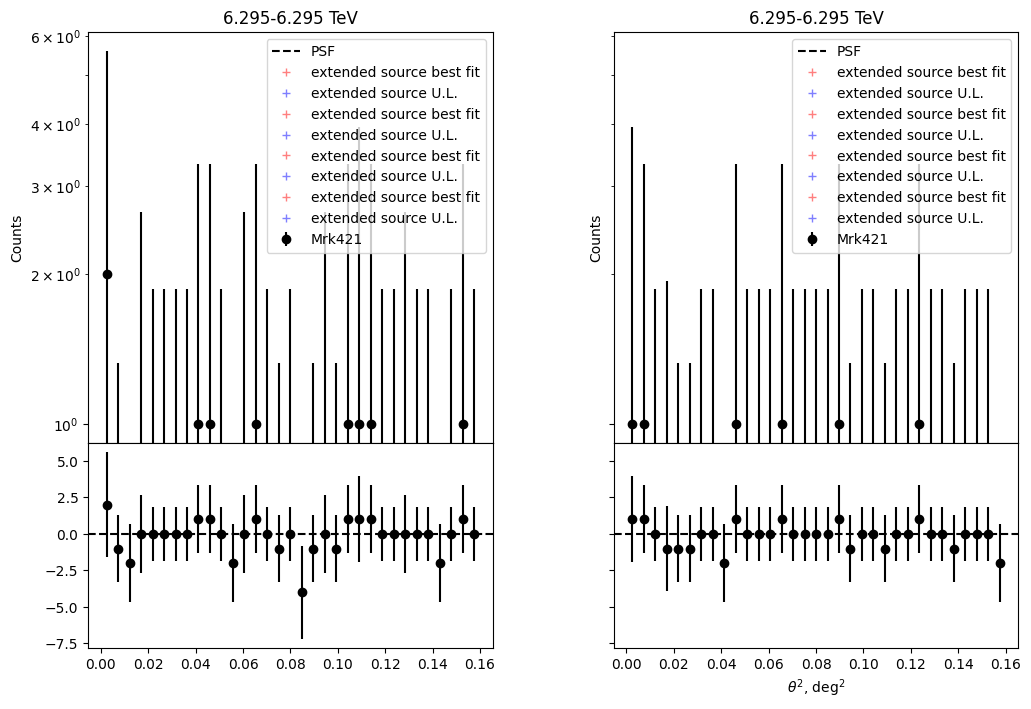

Best fit extended plus point gives chi2: 5.51718949307383
Best fit extended plus point gives chi2: 5.651214755195755
Best fit extended plus point gives chi2: 5.726600931772252
Best fit extended plus point gives chi2: 5.7484494450964165


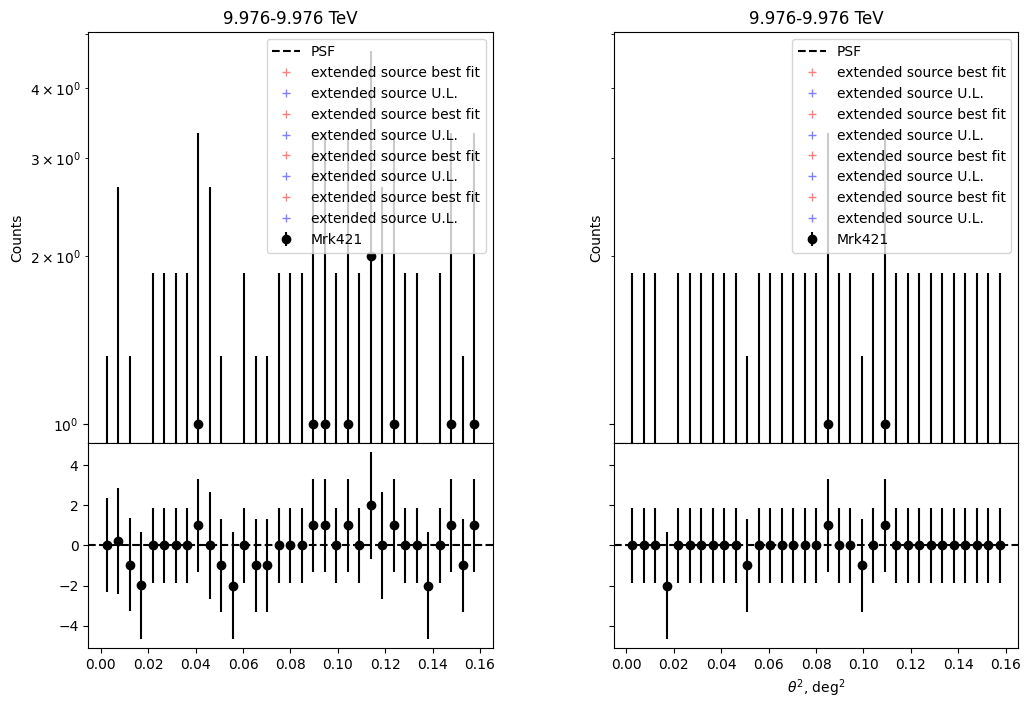

Best fit extended plus point gives chi2: 3.139436462475263
Best fit extended plus point gives chi2: 3.118071228215318
Best fit extended plus point gives chi2: 3.1019437114489667
Best fit extended plus point gives chi2: 3.096153028307526


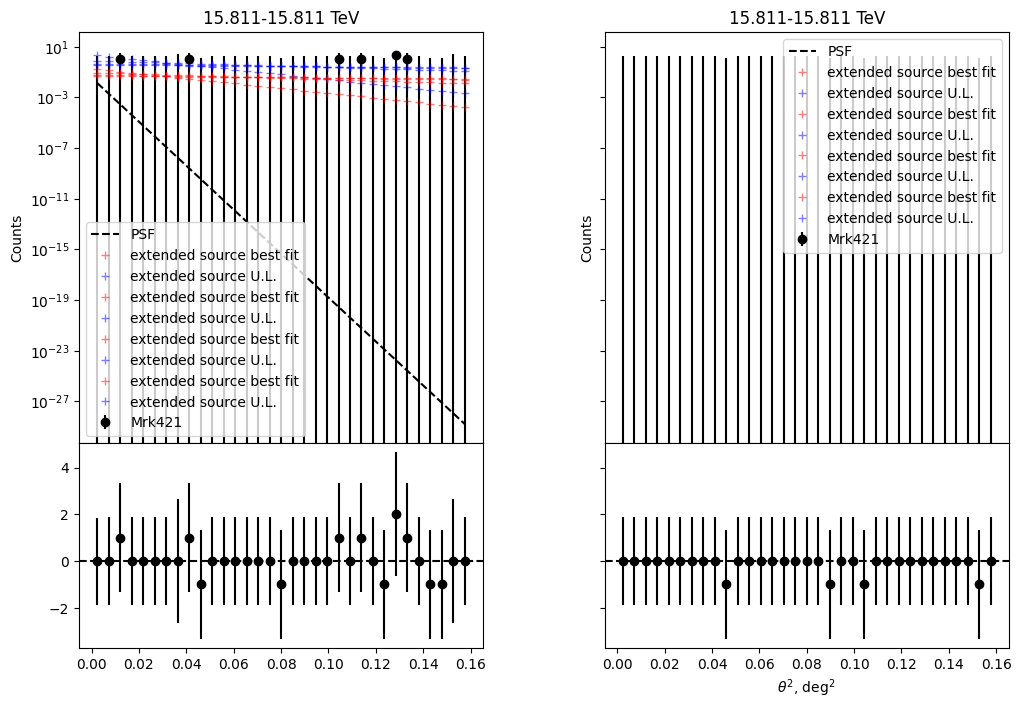

Best fit extended plus point gives chi2: 1.2671642193295636
Best fit extended plus point gives chi2: 1.2775601136449828
Best fit extended plus point gives chi2: 1.2784280037819773
Best fit extended plus point gives chi2: 1.2784765578794797


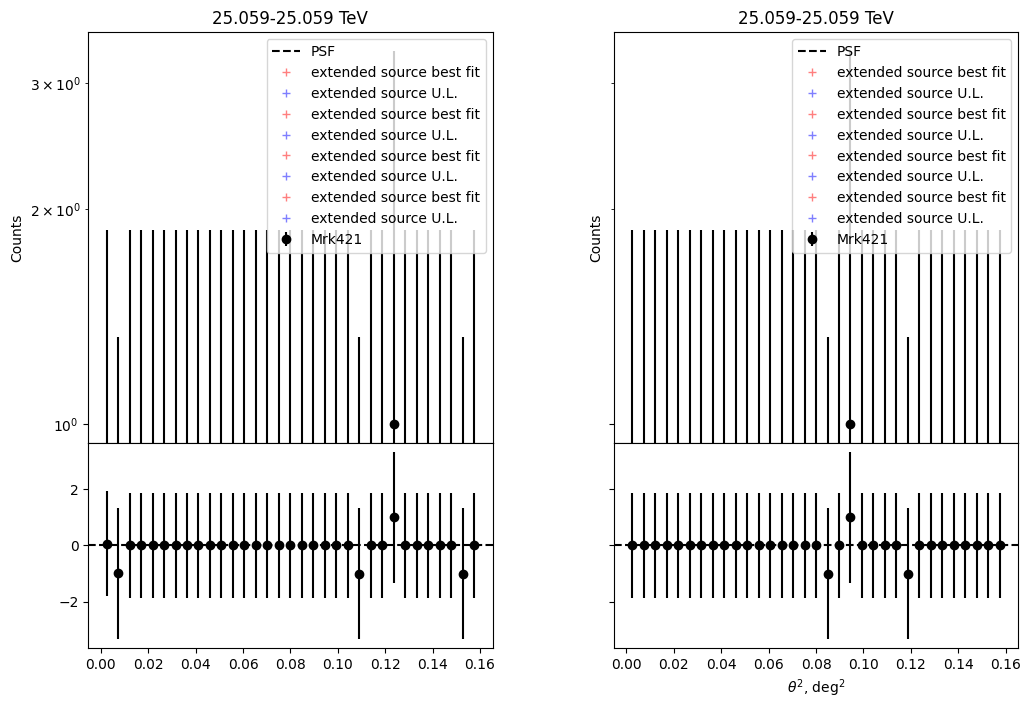

Best fit extended plus point gives chi2: 1.0919873295244824
Best fit extended plus point gives chi2: 1.081213046039122
Best fit extended plus point gives chi2: 1.0764175864446057
Best fit extended plus point gives chi2: 1.075140902067758


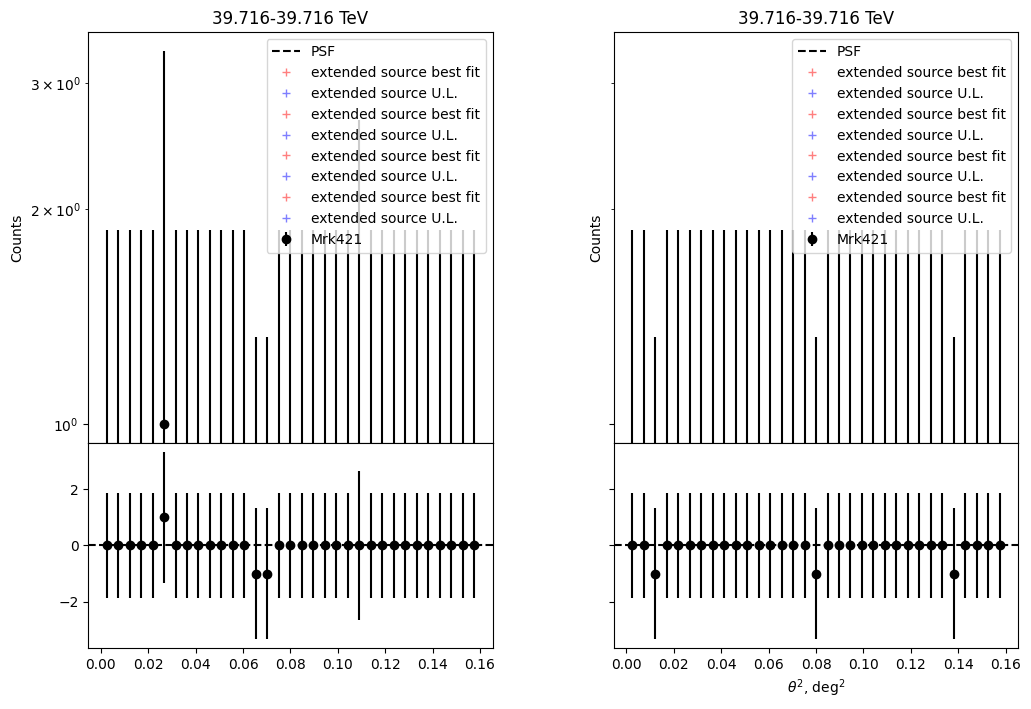

In [48]:
flux_ratios = calculate_UL_merged(cts_40deg, cts_err_40deg, psf_hbu_40deg, cts_20deg, cts_err_20deg, psf_hbu_20deg)

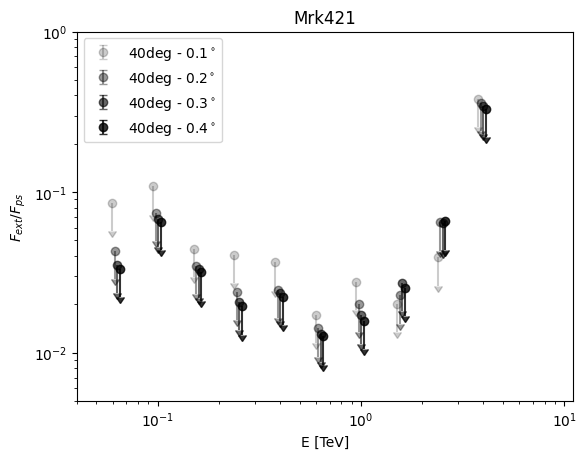

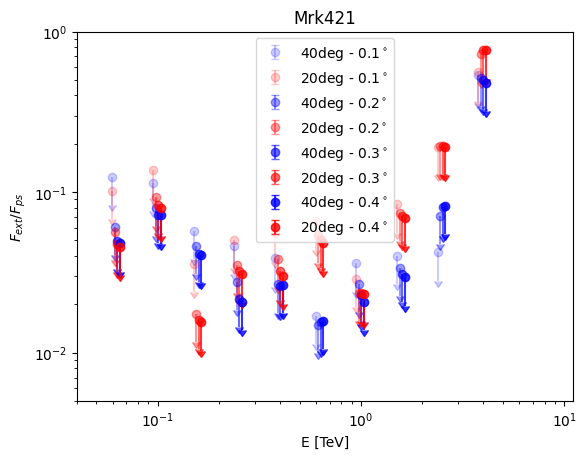

In [49]:
for i, flux_ratio in enumerate(flux_ratios):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio,flux_ratio/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='black')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.005, 1)
plt.legend()
plt.title(f"{name}")
plt.savefig(f'./images/UL_{name}_DC.png', dpi=300, bbox_inches='tight')
plt.show()

for i, (flux_ratio_40deg, flux_ratio_20deg) in enumerate(zip(flux_ratios_40deg, flux_ratios_20deg)):
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_40deg,flux_ratio_40deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="40deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='blue')
    plt.errorbar(e*(0.95*1.03**i), flux_ratio_20deg,flux_ratio_20deg/3, alpha=0.2+0.2*i, uplims=True, linestyle='none',marker='o', label="20deg - "+str(round(sigmas_ext[i],3))+r'$^\circ$',color='red')
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$F_{ext}/F_{ps}$")
plt.xlabel("E [TeV]")
plt.xlim(0.04,11)
plt.ylim(0.005, 1)
plt.legend()
plt.title(f"{name}")
plt.savefig(f'./images/UL_{name}_DC_2angles.png', dpi=300, bbox_inches='tight')

In [32]:
flux_ratios

array([[8.58544523e-02, 1.08735523e-01, 4.43744358e-02, 4.08285605e-02,
        3.62007594e-02, 1.71758463e-02, 2.75476877e-02, 2.01165062e-02,
        3.92522143e-02, 3.78986184e-01, 8.08143519e+00, 3.47066484e+00,
        1.22740021e+01, 1.04675300e+01, 1.27723749e+01],
       [4.30411901e-02, 7.46654408e-02, 3.48126676e-02, 2.38878421e-02,
        2.47611316e-02, 1.42159102e-02, 2.01874497e-02, 2.27361367e-02,
        6.48731759e-02, 3.60762107e-01, 6.82378194e+00, 4.72563924e+00,
        9.01620144e+00, 1.27723758e+01, 1.04675300e+01],
       [3.53114899e-02, 6.80775840e-02, 3.29981544e-02, 2.06717002e-02,
        2.35329644e-02, 1.31396712e-02, 1.70869694e-02, 2.71773374e-02,
        6.38819277e-02, 3.44615568e-01, 6.55752032e+00, 6.27779519e+00,
        7.84376138e+00, 1.30291006e+01, 9.76325418e+00],
       [3.32751278e-02, 6.53872757e-02, 3.17155894e-02, 1.94516519e-02,
        2.22836081e-02, 1.26326386e-02, 1.57598081e-02, 2.54848582e-02,
        6.56769094e-02, 3.30323719e-0